# **Project Name**    -  DeepCSAT Project



##### **Project Type**    - Classification
##### **Contribution**    - Individual


# **Problem Statement**


**OVERVIEW**


Customer satisfaction is key in e-commerce, affecting loyalty, repeat purchases, and referrals. Surveys are time-consuming and may not capture the full customer experience. Deep learning allows companies to predict satisfaction scores in real time, providing insights into service quality and enabling faster improvement.

**Project Goal**

This project uses Deep Learning, specifically Artificial Neural Networks (ANN), to predict Customer Satisfaction (CSAT) scores. In e-commerce, analysing customer interactions and feedback is crucial for improving service quality, retaining customers, and driving business growth. By using neural network models, the project aims to accurately forecast CSAT scores from various interaction-related features, providing actionable insights for service enhancements and strategic decision-making.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and ANN building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.utils import class_weight

import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')


### Dataset Loading

In [ ]:
csat_df= pd.read_csv('/Users/biplab/Downloads/Labmentix - DEEP-CSAT Project/eCommerce_Customer_support_data.csv')

### Dataset First View

In [ ]:
csat_df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Shape

In [ ]:
csat_df.shape

(85907, 20)

### Dataset Info

In [ ]:
csat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicates Values 

In [ ]:
len(csat_df[csat_df.duplicated()])

0

#### Missing Values

In [ ]:
csat_df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


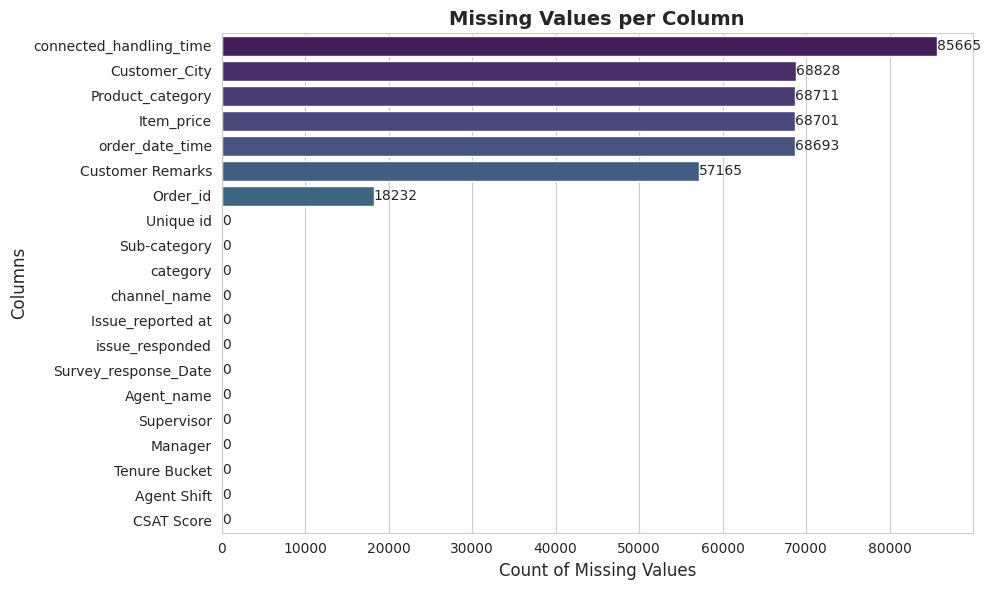

In [ ]:
# Missing Values Visualization
missing_values = csat_df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")  
barplot = sns.barplot(
    x=missing_values.values,
    y=missing_values.index,
    palette="viridis"  
)

for index, value in enumerate(missing_values.values):
    plt.text(value + 0.5, index, str(value), va='center')

plt.xlabel("Count of Missing Values", fontsize=12)
plt.ylabel("Columns", fontsize=12)
plt.title("Missing Values per Column", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### **What did you know about your dataset?**

The dataset, sourced from the e-commerce industry, analyses Customer Satisfaction Score (CSAT) and its key drivers.

CSAT, a crucial KPI, reflects customer satisfaction with products, services, or the overall shopping experience. In e-commerce, it evaluates factors like product quality, website usability, delivery speed, and customer service.

CSAT not only highlights customer perceptions but also shapes short-term and long-term business growth.

The dataset contains 85,907 rows and 20 columns. While it lacks duplicates, some columns have missing values, particularly in:

* Customer_city
* Product_category
* Item_price
* Order_id
* Order_date_time
* Customer_remarks
* Connected_handling_time

This dataset provides a foundation for exploring patterns, identifying pain points, and uncovering actionable insights to optimise the e-commerce customer experience and improve CSAT performance.


## ***2. Understanding Your Variables***

In [ ]:
csat_df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [ ]:
csat_df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


## **Dataset Description**

**Unique id:** A unique identifier for each record (integer).

**Channel name:** The name of the customer service channel (object/string), with 3 unique names.

**Category:** The category of the interaction (object/string), with 12 unique categories.

**Sub-category:** The sub-category of the interaction (object/string), with 57 unique sub-categories.

**Customer remarks:** Feedback provided by the customer (object/string).

**Order id:** The identifier for the order associated with the interaction (integer).

**Order date time:** The date and time of the order (datetime).

**Issue reported at:** The timestamp when the issue was reported (datetime).

**Issue responded:** The timestamp when the issue was responded to (datetime).

**Survey response date:** The date of the customer survey response (datetime).

**Customer city:** The city of the customer (object/string), with 1782 unique names.

**Product category:** The category of the product (object/string), with 9 unique categories.

**Item price:** The price of the item (float).

**Connected handling time:** The time taken to handle the interaction (float).

**Agent name:** The name of the customer service agent (object/string), with 1371 unique names.

**Supervisor:** The name of the supervisor (object/string), with 40 unique names.

**Manager:** The name of the manager (object/string), with 6 unique names.

**Tenure bucket:** The bucket categorising agent tenure (object/string).

**Agent shift:** The shift timing of the agent (object/string).

**CSAT score:** The customer satisfaction (CSAT) score (integer) (target variable).

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each column
for col in csat_df.columns:
    print(f"Column: {col} --> Unique Values: {csat_df[col].nunique()}")

Column: Unique id --> Unique Values: 85907
Column: channel_name --> Unique Values: 3
Column: category --> Unique Values: 12
Column: Sub-category --> Unique Values: 57
Column: Customer Remarks --> Unique Values: 18231
Column: Order_id --> Unique Values: 67675
Column: order_date_time --> Unique Values: 13766
Column: Issue_reported at --> Unique Values: 30923
Column: issue_responded --> Unique Values: 30262
Column: Survey_response_Date --> Unique Values: 31
Column: Customer_City --> Unique Values: 1782
Column: Product_category --> Unique Values: 9
Column: Item_price --> Unique Values: 2789
Column: connected_handling_time --> Unique Values: 211
Column: Agent_name --> Unique Values: 1371
Column: Supervisor --> Unique Values: 40
Column: Manager --> Unique Values: 6
Column: Tenure Bucket --> Unique Values: 5
Column: Agent Shift --> Unique Values: 5
Column: CSAT Score --> Unique Values: 5


## 3. **Data Preprocessing**

### Handling Missing Values

In [ ]:
# Count missing values per column
missing_values = csat_df.isnull().sum().sort_values(ascending=False)
print("\nMissing Values per Column:\n", missing_values)


# Fill missing categorical columns with mode
for col in csat_df.select_dtypes(include=['object']).columns:
    csat_df[col].fillna(csat_df[col].mode()[0], inplace=True)

# Fill missing numerical columns with median
for col in csat_df.select_dtypes(include=['float64','int64']).columns:
    csat_df[col].fillna(csat_df[col].median(), inplace=True)


Missing Values per Column:
 connected_handling_time    85665
Customer_City              68828
Product_category           68711
Item_price                 68701
order_date_time            68693
Customer Remarks           57165
Order_id                   18232
Unique id                      0
Sub-category                   0
category                       0
channel_name                   0
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


In [ ]:
# Copy dataset for future use
final_df = csat_df.copy()

# We can drop the ‘Order_id’ column as it’s not relevant to our analysis
final_df.drop(columns=['Order_id'], inplace=True)

In [ ]:
final_df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [ ]:
# Handling column 'Customer Remarks'
final_df['Customer Remarks'] = final_df['Customer Remarks'].fillna("No Review")

In [ ]:
# Handle categorical missing values
for col in ['Customer_City', 'Product_category']:
    if col in final_df.columns:
        # Fill with "Unknown"
        final_df[col] = final_df[col].fillna("Unknown")
        

In [ ]:
# Handle numerical missing values
if 'Item_price' in final_df.columns:
    final_df['Item_price'] = final_df['Item_price'].fillna(final_df['Item_price'].median())

In [ ]:
# Handle 'order_date_time'
if 'order_date_time' in final_df.columns:
    final_df['order_date_time'] = pd.to_datetime(final_df['order_date_time'], errors='coerce')

# Impute missing values in 'order_date_time' with mode
final_df['order_date_time'].fillna(final_df['order_date_time'].mode()[0], inplace=True)

In [ ]:
# Impute missing values in numerical columns ('connected_handling_time' and 'item_price')
# Impute 'connected_handling_time' with mean
final_df['connected_handling_time'].fillna(final_df['connected_handling_time'].mean(), inplace=True)


#### Connected_handling_time is a known driver of CSAT, but it’s unreliable due to 99% missing values.

We created a binary feature → has_handling_time (1 if present, 0 if missing) to learn if handling time was recorded, which may correlate with customer dissatisfaction.

In [ ]:
# Final Check
print("✅ Final Dataset Shape:", final_df.shape)
print("\n✅ Missing Values After Preprocessing:\n", final_df.isnull().sum().sort_values(ascending=False).head())

✅ Final Dataset Shape: (85907, 19)

✅ Missing Values After Preprocessing:
 Unique id           0
channel_name        0
category            0
Sub-category        0
Customer Remarks    0
dtype: int64


In [ ]:
final_df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,Good,2023-09-08 11:55:00,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,Good,2023-09-08 11:55:00,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,Good,2023-09-08 11:55:00,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,Good,2023-09-08 11:55:00,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,Good,2023-09-08 11:55:00,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


## 4. **Data Wrangling (Exploratory Data Analaysis)**

In [ ]:
# Create a copy of the dataset
final_df1 = final_df.copy()

# Count customers with the highest satisfaction score (CSAT = 5)
print("No. of customers interaction and feedbacks with highest customer satisfaction scores:",
      len(final_df1[final_df1['CSAT Score'] == 5]))

# Store data for highest CSAT scores
df_best_score = final_df1[final_df1['CSAT Score'] == 5]

# Store data for lowest CSAT scores
df_least_score = final_df1[final_df1['CSAT Score'] == 1]


No. of customers interaction and feedbacks with highest customer satisfaction scores: 59617


### Distribution of Target Variable (CSAT Score)

In [ ]:
final_df1['CSAT Score'].value_counts()

,count
CSAT Score,
5,59617
1,11230
4,11219
3,2558
2,1283


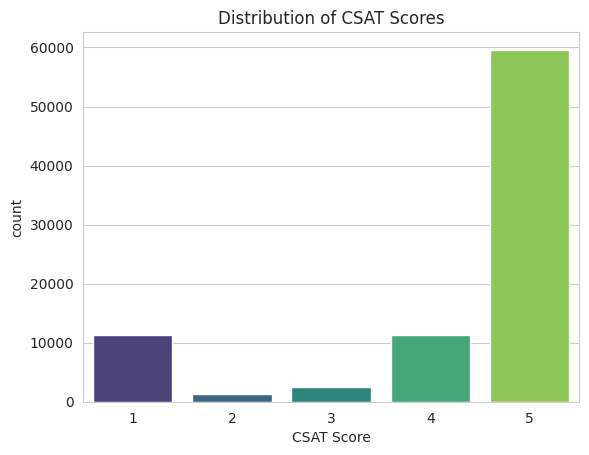

In [ ]:
sns.countplot(data=final_df1, x="CSAT Score", palette="viridis")
plt.title("Distribution of CSAT Scores")
plt.show()

## Categorical Feature Analysis

### Channel vs CSAT

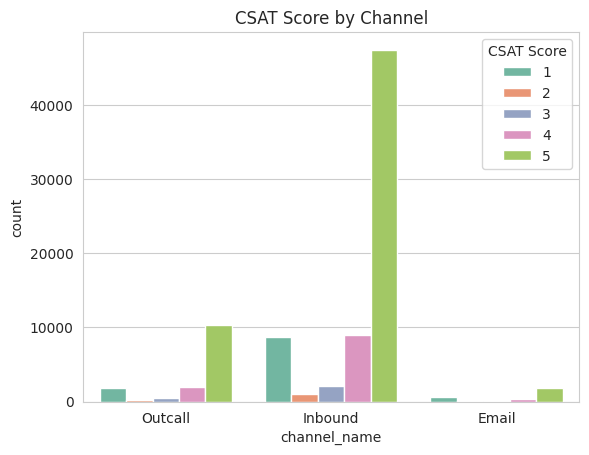

In [ ]:
sns.countplot(data=final_df1, x="channel_name", hue="CSAT Score", palette="Set2")
plt.title("CSAT Score by Channel")
plt.show()

### Agent Shift vs CSAT

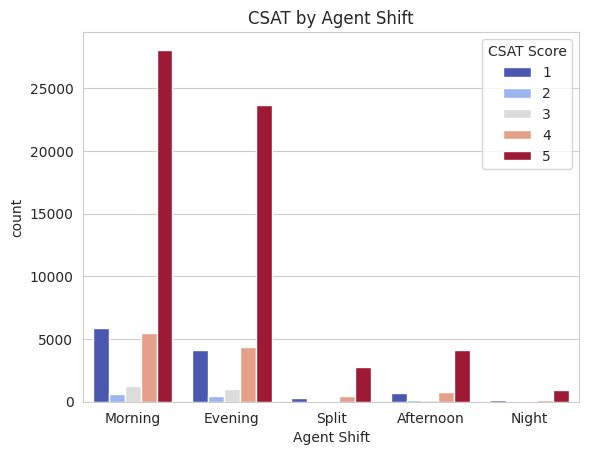

In [ ]:
sns.countplot(data=final_df1, x="Agent Shift", hue="CSAT Score", palette="coolwarm")
plt.title("CSAT by Agent Shift")
plt.show()

## Numerical Feature Analysis

### Item Price Distribution

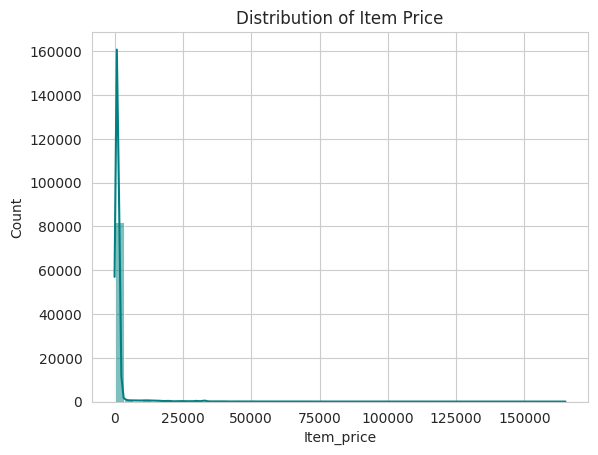

In [ ]:
sns.histplot(final_df1["Item_price"], kde=True, bins=50, color="teal")
plt.title("Distribution of Item Price")
plt.show()

### Correlation Analysis (Numerical)

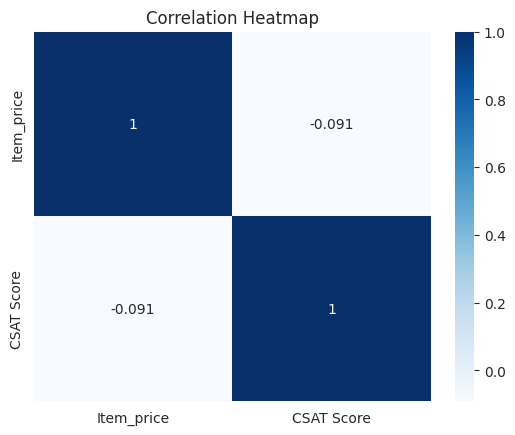

In [ ]:
corr = final_df1[["Item_price", "CSAT Score"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

### Top 5 Product Category with highest Customer Satisfaction Score

In [ ]:
# Group the data by Product_category and Customer satisfaction score

grouped_df = df_best_score.groupby('Product_category').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:5]

,Count
Product_category,
Electronics,51865
LifeStyle,2689
Books & General merchandise,2117
Mobile,982
Home,832


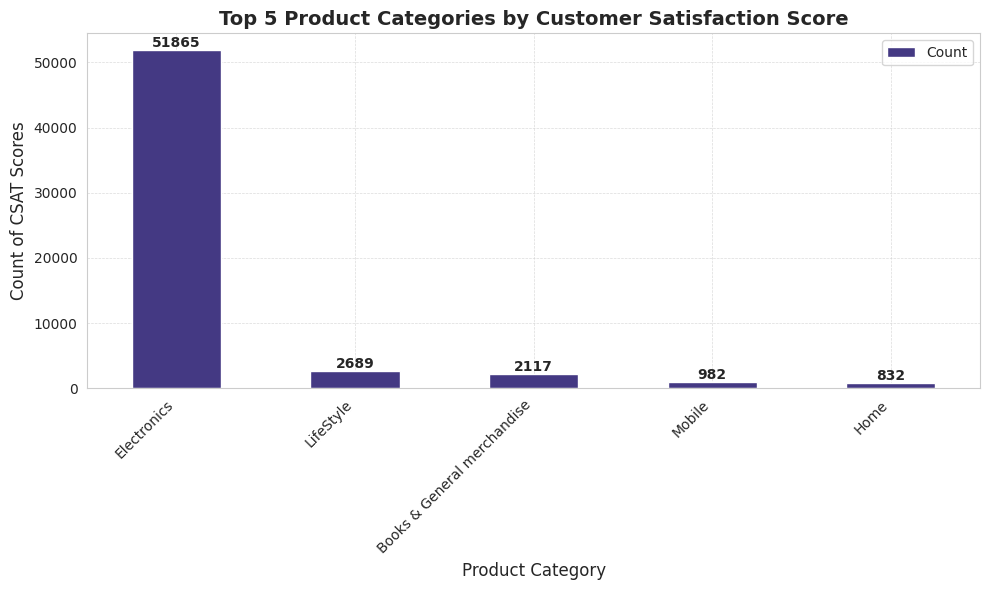

In [ ]:
# Top 5 product categories with highest CSAT Scores

fig, ax = plt.subplots(figsize=(10, 6))

# bar plot with color palette

bars = grouped_df[:5].plot(
    kind='bar',
    ax=ax,
    color=sns.color_palette("viridis", len(grouped_df[:5]))
)

# Adding labels and title

ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Count of CSAT Scores', fontsize=12)
ax.set_title('Top 5 Product Categories by Customer Satisfaction Score', fontsize=14, fontweight='bold')

# Rotating the x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Adding value labels on bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Adding grid for better readability
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)

# Tight layout
plt.tight_layout()

# Show the plot
plt.show()


### **Top 5 Category with highest customer satisfaction score**

In [ ]:
# Group the Customer_City data by Customer satisfaction score

grouped_df = df_best_score.groupby('category').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:5]

,Count
category,
Returns,31977
Order Related,15090
Refund Related,3137
Product Queries,2257
Shopzilla Related,2009


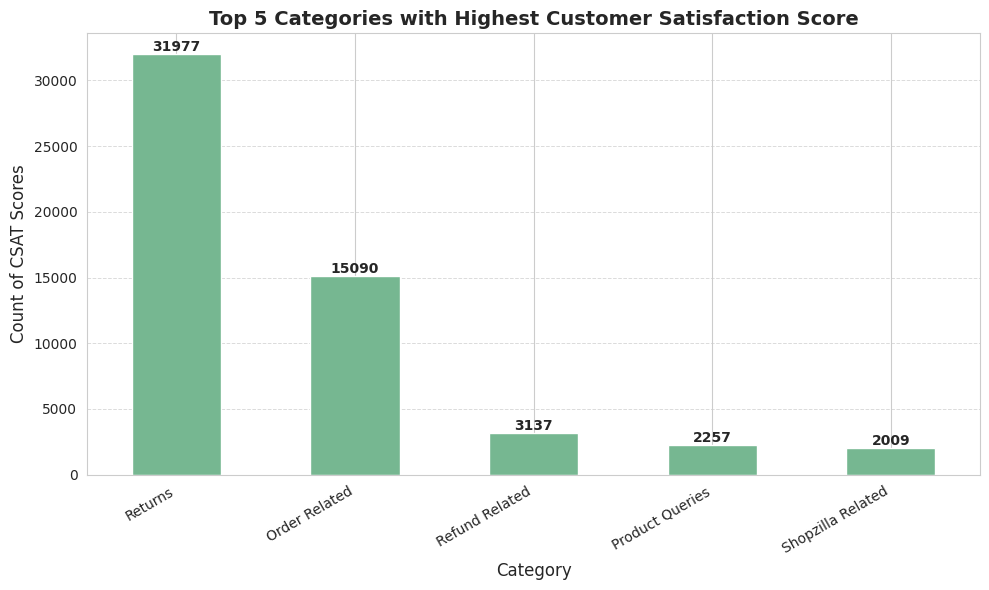

In [ ]:
# Improved bar chart for Top 5 Categories by CSAT Score
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with custom colors
bars = grouped_df[:5].plot(
    kind='bar',
    ax=ax,
    legend=False,
    color=sns.color_palette("crest", len(grouped_df[:5]))
)

# Adding labels and title
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count of CSAT Scores', fontsize=12)
ax.set_title('Top 5 Categories with Highest Customer Satisfaction Score', fontsize=14, fontweight='bold')

# Rotating x-axis labels for better readability
plt.xticks(rotation=30, ha='right')

# Adding value labels on top of bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Adding subtle grid
ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Tight layout for neatness
plt.tight_layout()

# Show the plot
plt.show()

### **Top 5 Sub Category with highest Customer Satisfaction Score**

In [ ]:
# Group the data by customer satisfaction score and sub-category.
grouped_df = df_best_score.groupby('Sub-category').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:5]

,Count
Sub-category,
Reverse Pickup Enquiry,15233
Return request,6718
Order status enquiry,4764
Delayed,4604
Fraudulent User,3279


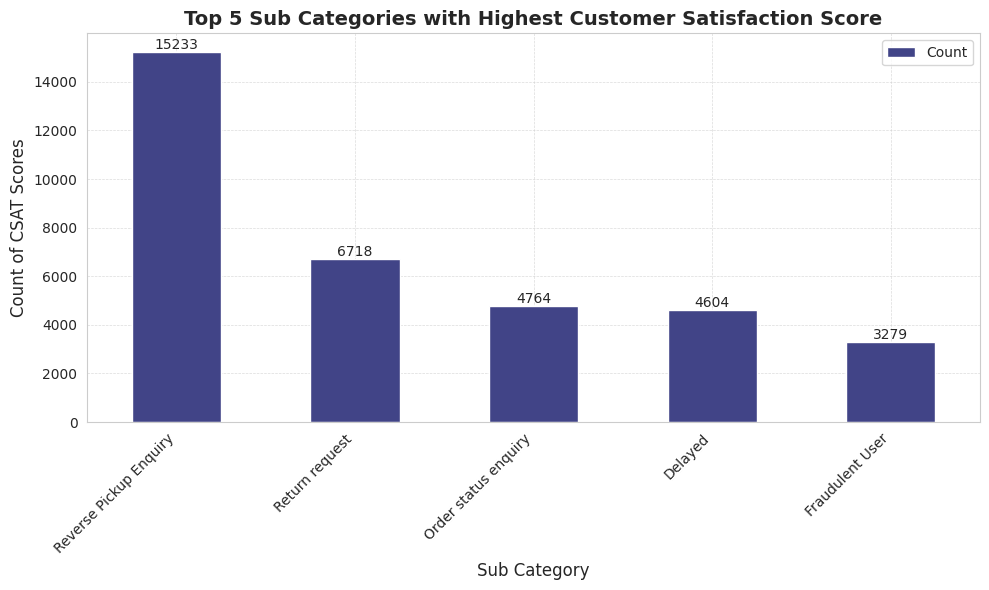

In [ ]:
# Plotting Top 5 Sub Categories by CSAT Score counts
fig, ax = plt.subplots(figsize=(10, 6))

# Top 5 aggregated values with a clean style
grouped_df[:5].plot(kind='bar', ax=ax, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(grouped_df[:5]))))

# Labels and title
ax.set_xlabel('Sub Category', fontsize=12)
ax.set_ylabel('Count of CSAT Scores', fontsize=12)
ax.set_title('Top 5 Sub Categories with Highest Customer Satisfaction Score', fontsize=14, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Add grid for readability
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt='%d')

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

### **Top 5 cities with highest customer satisfaction score**

In [ ]:
# Groupby Customer_City Wise w.r.t Customer satisfaction score data
grouped_df = df_best_score.groupby('Customer_City').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:5]

,Count
Customer_City,
HYDERABAD,49354
NEW DELHI,425
PUNE,226
MUMBAI,214
BANGALORE,201


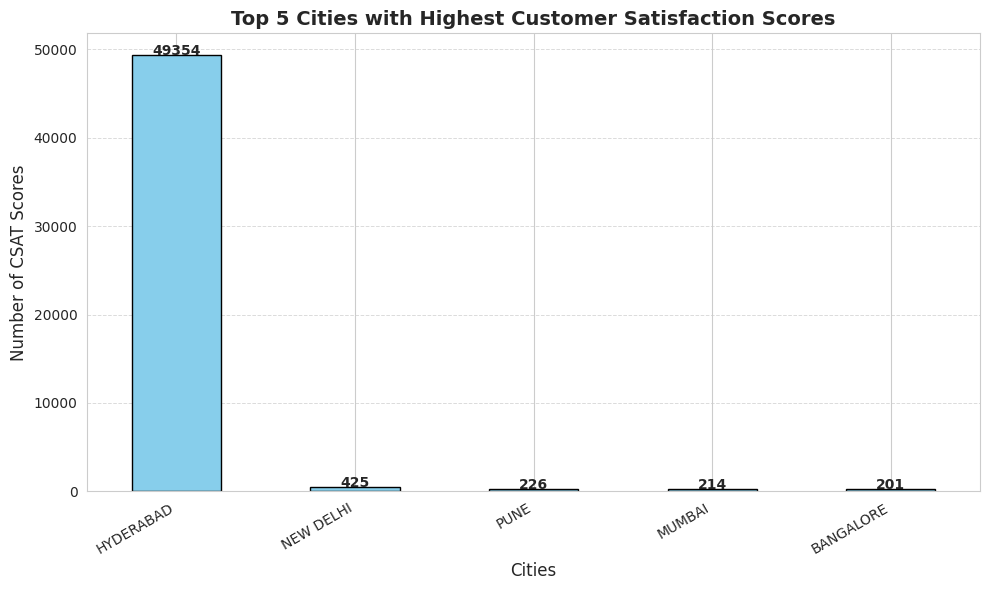

In [ ]:
# Plotting the top 5 cities by CSAT score counts
fig, ax = plt.subplots(figsize=(10, 6))

# Plot as bar chart with custom colors
grouped_df[:5].plot(kind='bar', ax=ax, color="skyblue", edgecolor="black", legend=False)

# Adding labels and title
ax.set_xlabel('Cities', fontsize=12)
ax.set_ylabel('Number of CSAT Scores', fontsize=12)
ax.set_title('Top 5 Cities with Highest Customer Satisfaction Scores', fontsize=14, fontweight='bold')

# Rotating the x-axis labels for better readability
plt.xticks(rotation=30, ha="right", fontsize=10)

# Adding grid (only horizontal for better readability)
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Annotating bar values
for i, v in enumerate(grouped_df[:5].values.flatten()):
    ax.text(i, v + 2, str(v), ha='center', fontsize=10, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

### **Top 3 best performing Managers**

In [ ]:
# Groupby Manager Wise as per Customer satisfaction score data
grouped_df = df_best_score.groupby('Manager').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:3]

,Count
Manager,
John Smith,17844
Michael Lee,12353
Jennifer Nguyen,10575


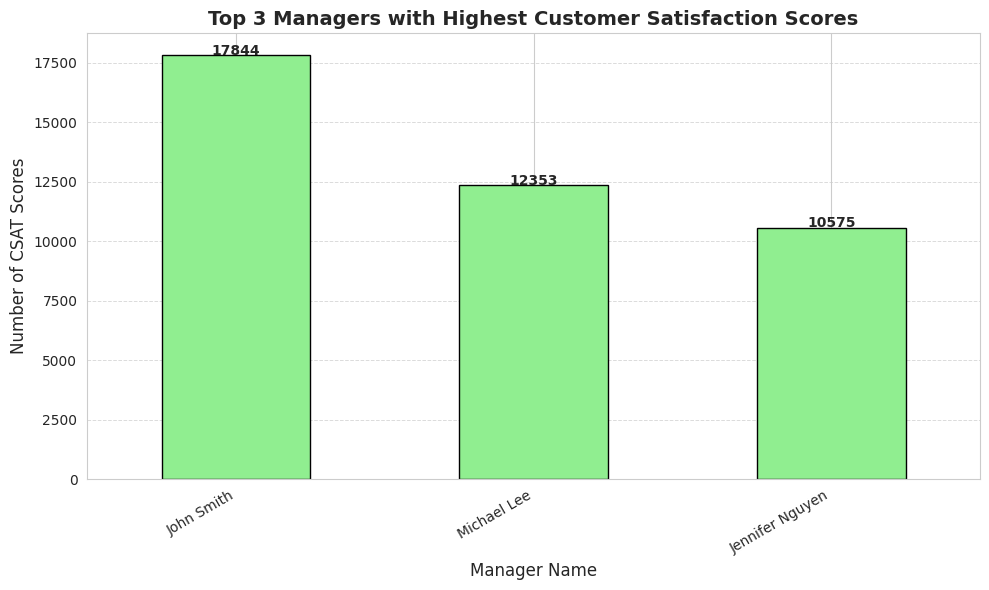

In [ ]:
# Plotting top 3 managers with highest CSAT scores
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot with better aesthetics
grouped_df[:3].plot(kind='bar', ax=ax, color="lightgreen", edgecolor="black", legend=False)

# Labels and title
ax.set_xlabel('Manager Name', fontsize=12)
ax.set_ylabel('Number of CSAT Scores', fontsize=12)
ax.set_title('Top 3 Managers with Highest Customer Satisfaction Scores', fontsize=14, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=30, ha="right", fontsize=10)

# Add horizontal grid only for readability
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Annotate values above bars
for i, v in enumerate(grouped_df[:3].values.flatten()):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.show()

### **Top 3 best performing Agents**

In [ ]:
# Groupby Agent_name Wise w.r.t Customer satisfaction score data
grouped_df = df_best_score.groupby('Agent_name').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:3]

,Count
Agent_name,
Wendy Taylor,299
David Smith,218
Timothy Huff,211


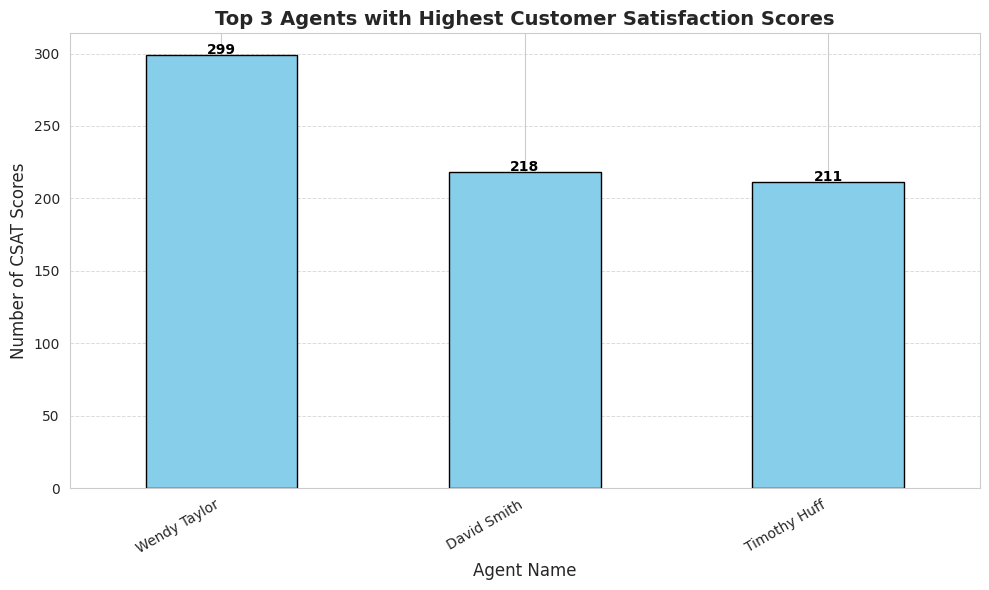

In [ ]:
# Plotting top 3 agents with highest CSAT scores
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar plot
grouped_df[:3].plot(kind='bar', ax=ax, color="skyblue", edgecolor="black", legend=False)

# Adding labels and title
ax.set_xlabel('Agent Name', fontsize=12)
ax.set_ylabel('Number of CSAT Scores', fontsize=12)
ax.set_title('Top 3 Agents with Highest Customer Satisfaction Scores', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha="right", fontsize=10)

# Add horizontal grid only
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Annotate bar values
for i, v in enumerate(grouped_df[:3].values.flatten()):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold', color="black")

# Adjust layout
plt.tight_layout()
plt.show()

### **Top 3 best performing Supervisors**

In [ ]:
# Groupby Supervisor Wise as per Customer satisfaction score data
grouped_df = df_best_score.groupby('Supervisor').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:3]

,Count
Supervisor,
Carter Park,2921
Elijah Yamaguchi,2870
Nathan Patel,2576


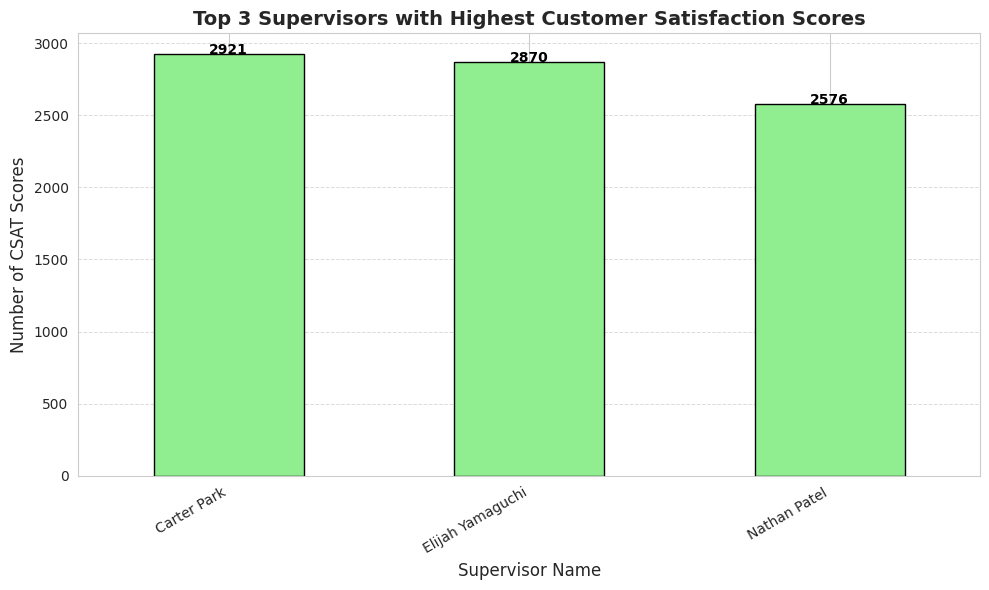

In [ ]:
# Plotting top 3 supervisors with highest CSAT scores
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar plot
grouped_df[:3].plot(kind='bar', ax=ax, color="lightgreen", edgecolor="black", legend=False)

# Adding labels and title
ax.set_xlabel('Supervisor Name', fontsize=12)
ax.set_ylabel('Number of CSAT Scores', fontsize=12)
ax.set_title('Top 3 Supervisors with Highest Customer Satisfaction Scores', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha="right", fontsize=10)

# Add horizontal grid only
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Annotate bar values on top of bars
for i, v in enumerate(grouped_df[:3].values.flatten()):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold', color="black")

# Adjust layout
plt.tight_layout()
plt.show()

### **Which tenure group of employees is performing the best?**

In [ ]:
# Groupby Supervisor Wise as per Customer satisfaction score data
grouped_df = df_best_score.groupby('Tenure Bucket').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:3]

,Count
Tenure Bucket,
>90,21678
On Job Training,16860
31-60,8301


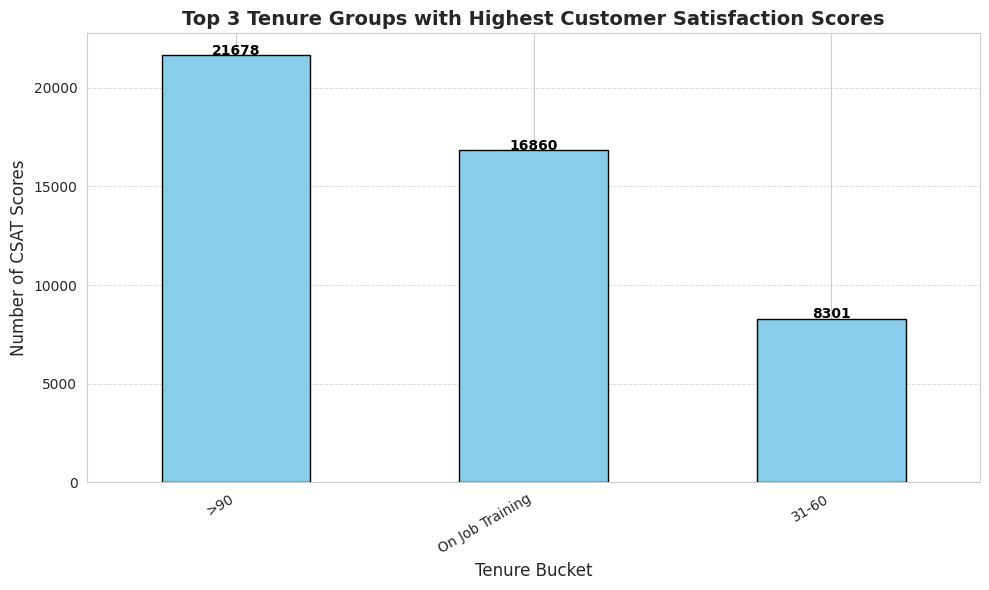

In [ ]:
# Plotting top 3 tenure buckets with highest CSAT scores
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar plot
grouped_df[:3].plot(kind='bar', ax=ax, color="skyblue", edgecolor="black", legend=False)

# Adding labels and title
ax.set_xlabel('Tenure Bucket', fontsize=12)
ax.set_ylabel('Number of CSAT Scores', fontsize=12)
ax.set_title('Top 3 Tenure Groups with Highest Customer Satisfaction Scores', fontsize=14, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha="right", fontsize=10)

# Add horizontal grid only
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Annotate bar values on top of bars
for i, v in enumerate(grouped_df[:3].values.flatten()):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold', color="black")

# Adjust layout
plt.tight_layout()
plt.show()

### **Which shift timings of agents is performing the best?**

In [ ]:
# Groupby Supervisor Wise as per Customer satisfaction score data
grouped_df = df_best_score.groupby('Agent Shift').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count',ascending=False)

grouped_df[:3]

,Count
Agent Shift,
Morning,28087
Evening,23680
Afternoon,4153


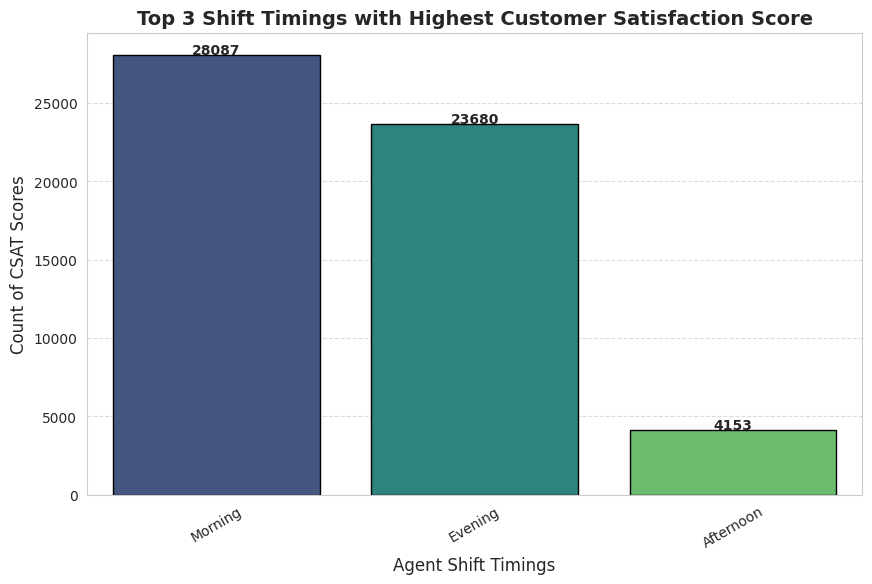

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Groupby Agent Shift Timings w.r.t Customer satisfaction score data
grouped_df = df_best_score.groupby('Agent Shift').agg(
    Count=('CSAT Score', 'size')
).sort_values(by='Count', ascending=False)

# Select top 3 shift timings
top_shifts = grouped_df[:3]

# Plotting with seaborn for better aesthetics
plt.figure(figsize=(10,6))
sns.barplot(x=top_shifts.index, y=top_shifts['Count'],
            palette="viridis", edgecolor="black")

# Adding labels and title
plt.xlabel('Agent Shift Timings', fontsize=12)
plt.ylabel('Count of CSAT Scores', fontsize=12)
plt.title('Top 3 Shift Timings with Highest Customer Satisfaction Score', fontsize=14, fontweight='bold')

# Annotate values on bars
for i, v in enumerate(top_shifts['Count']):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=30)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


### **How response time impacts the customer satisfaction score?**

In [ ]:
# Response Time Analysis by CSAT Score 

# Ensure datetime format
final_df1['Issue_reported at'] = pd.to_datetime(final_df1['Issue_reported at'], dayfirst=True)
final_df1['issue_responded'] = pd.to_datetime(final_df1['issue_responded'], dayfirst=True)

# Calculate response time
final_df1['Response_Time'] = final_df1['issue_responded'] - final_df1['Issue_reported at']

# Convert to seconds for aggregation
final_df1['Response_Time_seconds'] = final_df1['Response_Time'].dt.total_seconds()

# Group by CSAT score → mean response time (in seconds)
grouped_df = (
    final_df1.groupby('CSAT Score', as_index=False)
    .agg(Mean_Response_Time_Seconds=('Response_Time_seconds', 'mean'))
    .sort_values(by='Mean_Response_Time_Seconds', ascending=False)
)

# Convert mean seconds back to timedelta for better readability
grouped_df['Mean_Response_Time'] = pd.to_timedelta(grouped_df['Mean_Response_Time_Seconds'], unit='s')

# Display results
print("\nAverage Response Time by CSAT Score:\n")
print(grouped_df)



Average Response Time by CSAT Score:

   CSAT Score  Mean_Response_Time_Seconds        Mean_Response_Time
0           1                21003.275156 0 days 05:50:03.275155833
1           2                16534.840218 0 days 04:35:34.840218239
2           3                11944.222048 0 days 03:19:04.222048475
3           4                 6928.943756 0 days 01:55:28.943756128
4           5                 5706.442122 0 days 01:35:06.442122213


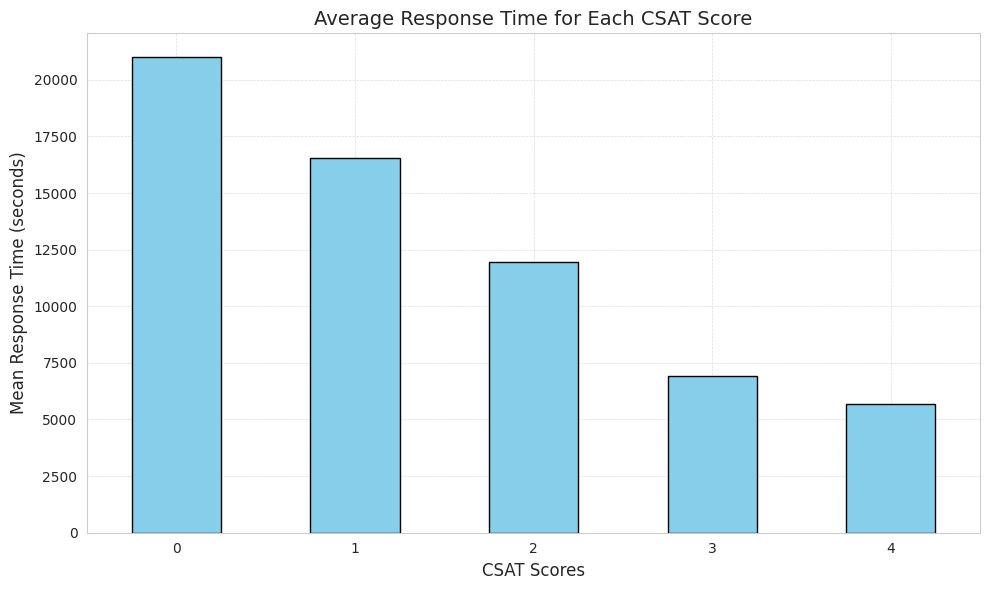

In [ ]:
# Plotting the data
fig, ax = plt.subplots(figsize=(10, 6))

# Plot only the 'Mean_Response_Time' column
grouped_df['Mean_Response_Time'].dt.total_seconds().plot(
    kind='bar',
    ax=ax,
    color='skyblue',
    edgecolor='black'
)

# Adding labels and title
ax.set_xlabel('CSAT Scores', fontsize=12)
ax.set_ylabel('Mean Response Time (seconds)', fontsize=12)
ax.set_title('Average Response Time for Each CSAT Score', fontsize=14)

# Rotating the x-axis labels for better readability
plt.xticks(rotation=0)

# Adding grid for better readability
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()


### What all manipulations have you done and insights you found?

**Answer:**

In this project, I preprocessed the dataset to ensure consistency and completeness.

For categorical variables, I filled missing values with “Unknown”. For text-based fields, I replaced nulls with “No Review”. For numerical features, I imputed missing values with the median to avoid skewing the data. For the *order\_date\_time* feature, I converted it to a datetime format and imputed missing values with the mode. For the *connected\_handling\_time* feature, since it was mostly missing, I engineered a binary flag.

After preprocessing, I performed Exploratory Data Analysis (EDA) to identify key trends.

* Electronics had the highest volume of cases (approximately 52K), followed by Lifestyle and Books.
* Returns (32K) and order-related issues (15K) dominated, with Reverse Pickup Enquiry being the top sub-category (approximately 15K).
* A large share of customers came from Hyderabad (approximately 49K).
* Managers like John Smith and Michael Lee handled the highest volumes, while agents like Wendy Taylor and David Smith stood out with the most cases.
* Most employees fell into the >90 days tenure bucket (approximately 21K), and the Morning shift had the highest workload (approximately 28K).

This analysis uncovered patterns in complaints, high-volume product categories, city-wise concentration, and workload distribution across shifts and teams. These insights are crucial for improving customer experience and resource allocation.



## **Data Visualisation, Storytelling, and Chart Experimentation: Unraveling Relationships Between Variables**

### **Chart - 1 - Pie Chart on Dependant Variable (CSAT Score) [Univarite Analysis**]

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64
 


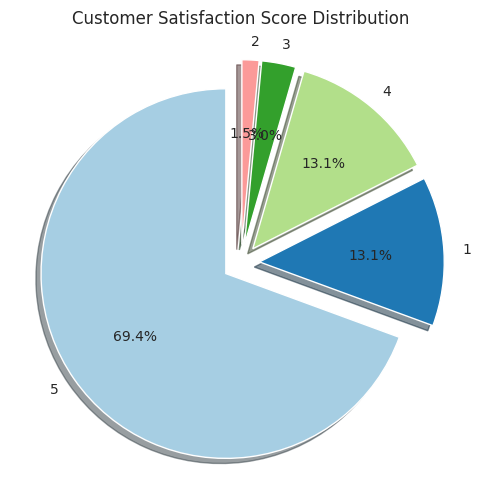

In [ ]:
# Chart - 1 visualization code
# Dependant Column Value Counts

# Display the value counts of the 'CSAT Score' column
print(final_df1['CSAT Score'].value_counts())
print(" ")

# Visualize the 'CSAT Score' value counts as a pie chart
final_df1['CSAT Score'].value_counts().plot(
    kind='pie',
    figsize=(15, 6),
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    labels=final_df1['CSAT Score'].value_counts().index,
    colors=plt.cm.Paired(range(len(final_df1['CSAT Score'].value_counts()))),
    explode=[0.1] * len(final_df1['CSAT Score'].value_counts())  # Slightly explode all slices for better visibility
)

# Set the title and display the plot
plt.title('Customer Satisfaction Score Distribution')
plt.ylabel('')  # Hide the y-label as it's redundant in a pie chart
plt.show()


### **1. Why was this chart chosen?**

A pie chart was chosen to effectively show the part-to-whole relationship of customer satisfaction levels. It provides an intuitive way to compare proportions at a glance, making it easy to identify dominant satisfaction levels and areas for improvement.

The analysis reveals that a majority of customers (59,617) rated the service with a CSAT Score of 5, accounting for 69.4% of total feedback. Around 15% of customers provided poor ratings, with 13.1% giving a score of 1, 3% a score of 3, and 1.5% a score of 2. Another 13.1% rated their experience with a score of 4, indicating areas for improvement.

While most customers are highly satisfied, a notable proportion (\~15%) experienced dissatisfaction, which warrants further investigation.

The positive impact of these insights is to focus on strengths and reinforce successful strategies across weaker areas.
Targeted improvements are crucial to address customer dissatisfaction and improve loyalty. By pinpointing problem areas like product quality, agent performance, and service delays, businesses can directly enhance customer experiences. These insights guide training, process improvements, and resource investments in areas most likely to improve customer satisfaction. Additionally, management can set measurable goals to reduce dissatisfaction while maintaining strong performance in existing high-satisfaction areas.

However, there are potential risks associated with neglecting dissatisfied customers or failing to address underlying issues. Over-focusing on fixing dissatisfied customers while ignoring satisfied ones may weaken loyalty, while ignoring issues behind poor scores could lead to customer churn, negative reviews, and revenue loss. Short-term fixes without addressing root causes may result in temporary score improvements but long-term decline in satisfaction.

In conclusion, the chart highlights both strengths and vulnerabilities. With nearly 70% of customers highly satisfied, the business has a strong foundation. However, addressing the 15% dissatisfied group is critical to avoid churn and ensure sustainable growth. Balanced management of both high and low performers will maximise positive business impact.


#### Chart - 2 - Agent Vs. Average Response Time Percentage (Bivariate with Categorical - Numerical)

           Agent_name  Average Response Time (seconds)
0    Christine Castro                     40915.714286
1  Virginia Mccormick                     34088.571429
2     Dennis Campbell                     32251.200000
3      Melissa Spence                     31560.000000
4       Glenda Powell                     31377.272727
5         John Nelson                     30621.052632
6           Ryan Khan                     30345.600000
7      Shane Humphrey                     30140.000000
8       Donald Jordan                     29545.714286
9      Elizabeth Rose                     29123.478261
 


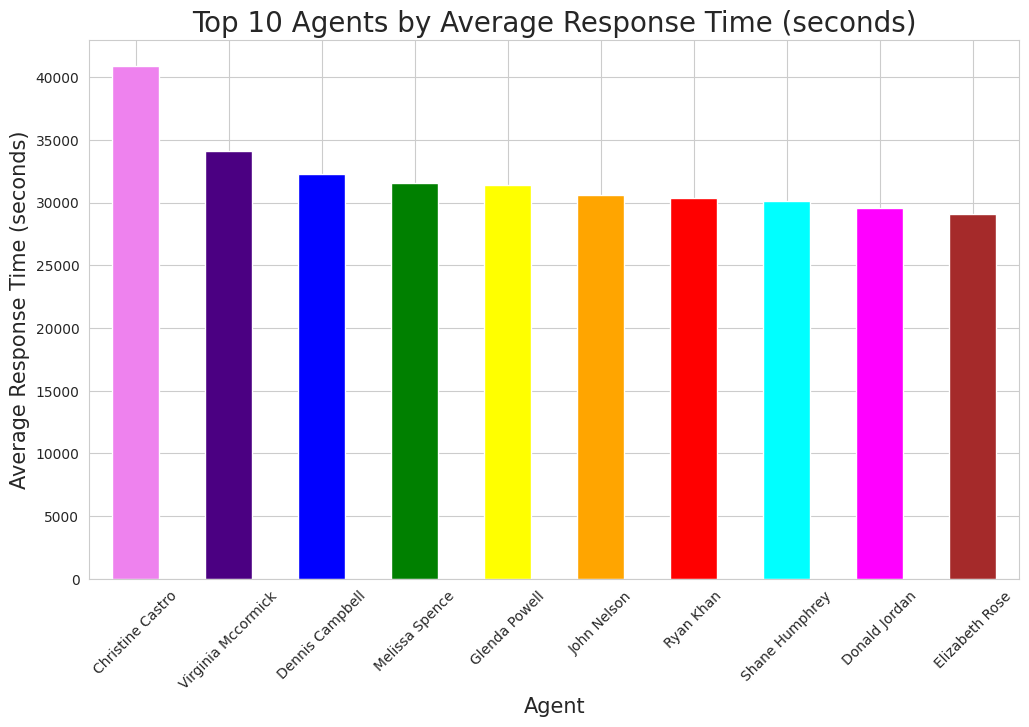

In [ ]:
# Chart - 2 visualization code
# Showing Average Response Time (seconds) for each Agent
# Display top 10 agents with highest average response time
print(
    (final_df1.groupby(['Agent_name'])['Response_Time_seconds']
     .mean()
     .sort_values(ascending=False)
     .reset_index(name="Average Response Time (seconds)")
     .head(10))
)
print(" ")

# Visualization - Top 10 Agents with highest average response time
plt.rcParams['figure.figsize'] = (12, 7)
top_agents = (final_df1.groupby(['Agent_name'])['Response_Time_seconds']
              .mean()
              .sort_values(ascending=False)
              .head(10))

top_agents.plot.bar(
    color=['violet', 'indigo', 'blue', 'green', 'yellow', 'orange', 'red', 'cyan', 'magenta', 'brown']
)

plt.title("Top 10 Agents by Average Response Time (seconds)", fontsize=20)
plt.xlabel('Agent', fontsize=15)
plt.ylabel('Average Response Time (seconds)', fontsize=15)
plt.xticks(rotation=45)
plt.show()


## 1. Why did you choose a bar chart?

A bar chart is most effective for comparing values across categories. Since the goal is to compare the average response time across different agents, a bar chart provides a clear and side-by-side visualisation of performance differences.

## 2. What are the insights from the chart?

The dataset covers 10 agents with varying average response times, ranging from 2.09 to 4.09 hours. Elizabeth Rose and Donald Jordan are the top performers, demonstrating efficient client handling. However, Christine Castro has the longest average response time, indicating a need for review and targeted training.

## 3. Do the insights support positive business impact? Are there any risks of negative growth?

Yes, the insights support positive business impact. Acknowledging agents like Elizabeth Rose and Donald Jordan can motivate them and encourage others to follow their example. Targeted training for agents with higher response times, such as Christine Castro, can reduce delays and improve CSAT. Additionally, understanding performance gaps allows managers to optimise workload distribution and identify systemic bottlenecks beyond individual performance.

However, there are potential risks of negative growth if these insights are ignored.

**Unaddressed Poor Performance:** Persistent high response times can lead to customer dissatisfaction, negatively impacting CSAT and retention.

**Demotivating Top Performers:** Lack of recognition for the fastest agents can reduce their motivation over time.

**Over-focus on Speed:** Chasing faster responses without prioritising quality can result in rushed or incomplete resolutions, damaging customer trust.


### Conclusion

The chart offers actionable insights to enhance customer service performance. By rewarding top performers and providing training to underperforming agents, businesses can raise CSAT scores, improve client retention, and improve overall service quality. However, if these insights are not implemented or if the focus solely shifts to speed without prioritising quality, the business risks declining customer satisfaction and potential negative growth.


#### **Chart - 3 - CSAT Score vs Item price (Bivariate)**

CSAT Score
1    3339.239537
2    2296.834762
3    2141.081314
4    1797.410910
5    1653.371236
Name: Item_price, dtype: float64
 


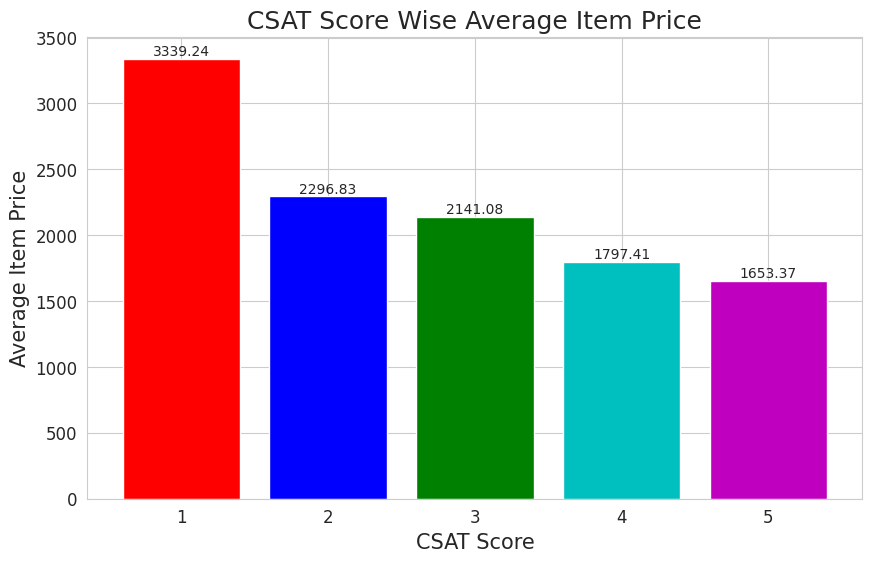

In [ ]:
# Chart - 4 visualization code
# CSAT Score wise average Item_price

# Calculate the average item price by CSAT Score
csat_avg_item_price = final_df1.groupby('CSAT Score')['Item_price'].mean()
print(csat_avg_item_price)
print(" ")

# Visualizing the CSAT Score wise average item price
plt.figure(figsize=(10, 6))
bars = plt.bar(csat_avg_item_price.index, csat_avg_item_price, color=['r', 'b', 'g', 'c', 'm'])

# Adding labels and title
plt.xlabel('CSAT Score', fontsize=15)
plt.ylabel('Average Item Price', fontsize=15)
plt.title('CSAT Score Wise Average Item Price', fontsize=18)
plt.xticks(csat_avg_item_price.index, fontsize=12)
plt.yticks(fontsize=12)

# Adding value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Display the plot
plt.show()

## 1. Why was a bar chart chosen?

A bar chart was selected because it effectively compares the average item prices across different CSAT score levels. Since CSAT is a categorical variable (1–5), bar charts are suitable for visualising differences in numerical measures (mean item price) across categories.

## 2. What insights are found from the chart?

The bar chart reveals that:

The average item price is highest when the CSAT score is 1 (lowest satisfaction).faction)**.
* TheThe average item price is lowest when the CSAT score is 5 (highest satisfaction).sfaction)**.

ThisThe data indicates a clear inverse relationship between item price and customer satisfaction. Higher prices are generally linked to lower customer satisfaction scores.

### 3. Will the gained insights help create a positive business impact?

Yes, positive impact is possible if used wisely. Businesses can reconsider pricing at higher ranges or add more value (e.g., warranties, freebies, better support) to justify the cost, thereby improving customer satisfaction. Additionally, these insights can help businesses group customers into segments (e.g., high-spending but less satisfied vs. budget-friendly and highly satisfied) and tailor promotions for each group.

However, there are also risks if mismanaged. Simply lowering prices might temporarily boost customer satisfaction but hurt profitability. Overemphasising price can limit improvements because customer satisfaction is multi-dimensional (service, quality, delivery).

### 4. Justification with Specific Reasons

The positive business impact can be achieved by aligning pricing and value delivery with customer expectations. For example, if higher-priced items include faster support or exclusive benefits, customers will feel the price is justified. Conversely, aggressive price cuts without perceived value addition may damage brand positioning (e.g., premium items losing exclusivity) and reduce profit margins, posing a negative growth risk.

In conclusion, the insights are highly actionable. By maintaining a balance between price, value, and customer expectations, companies can boost customer satisfaction, retain customers, and ensure long-term growth while avoiding risks of negative financial impact.



### **Chart - 4- Column wise Histogram & Box Plot Univariate Analysis**

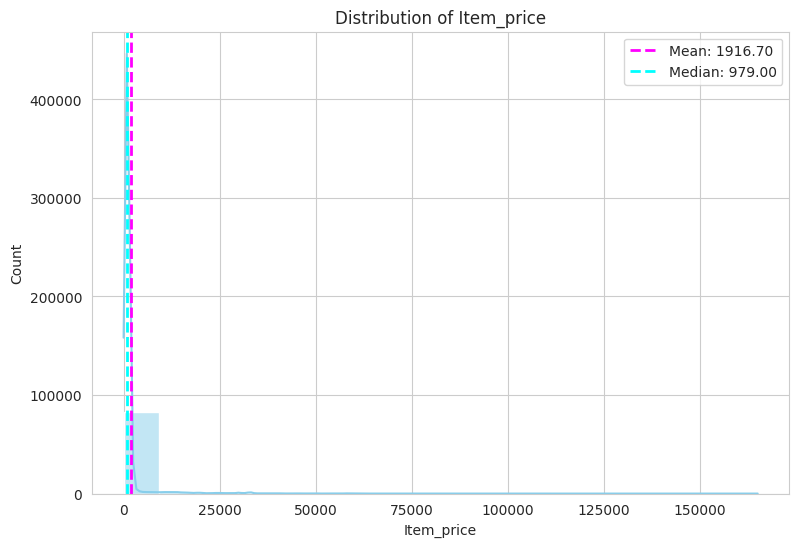

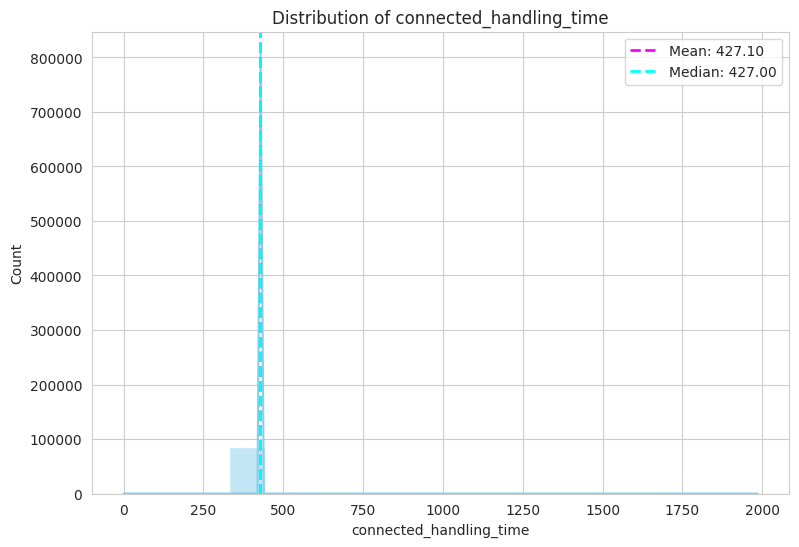

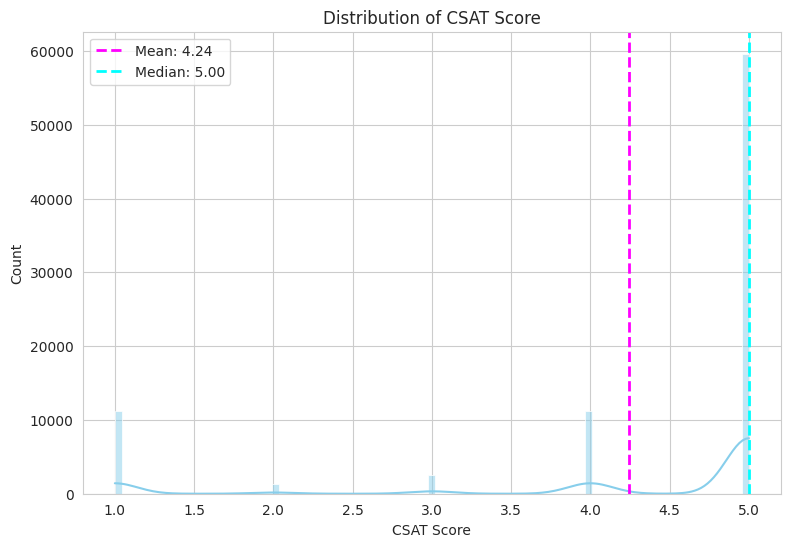

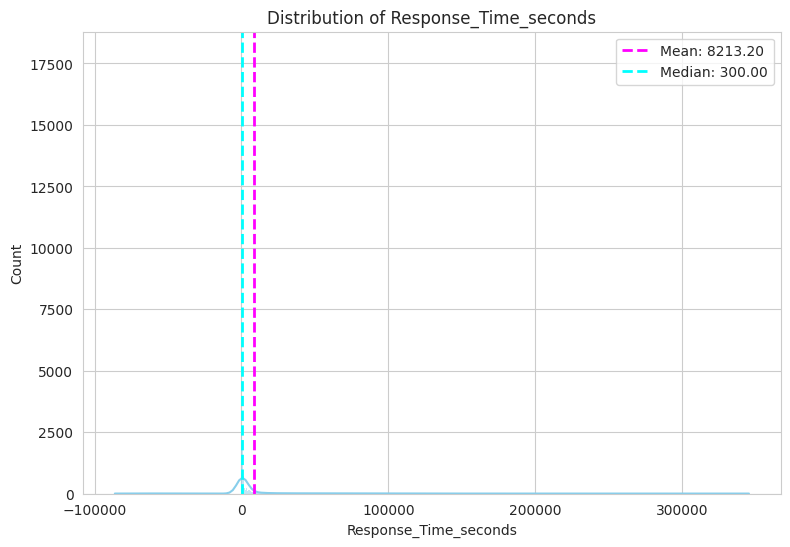

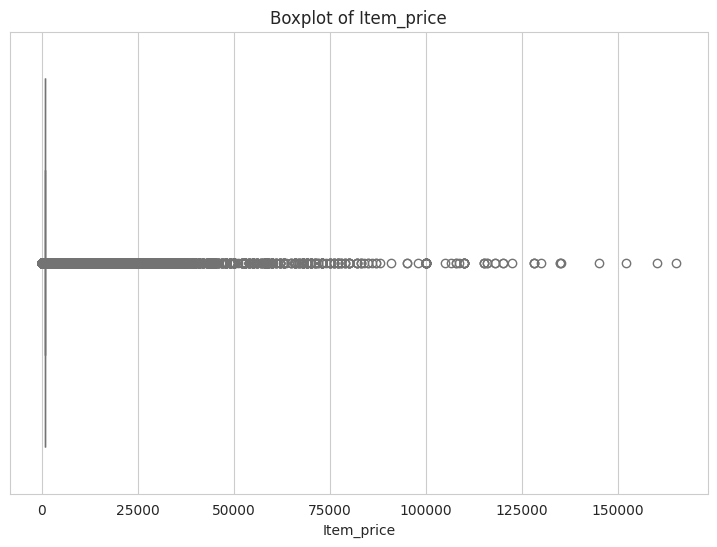

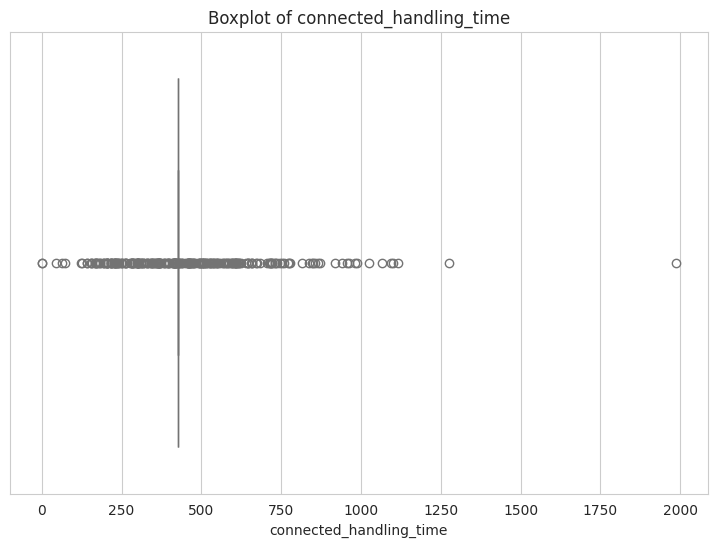

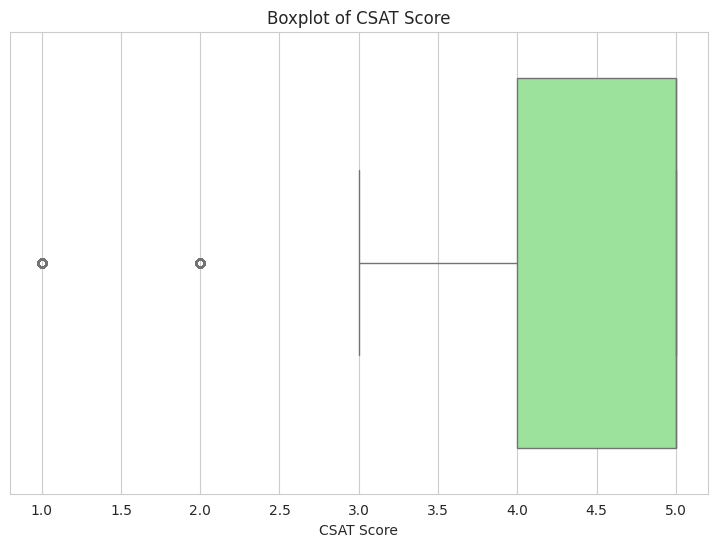

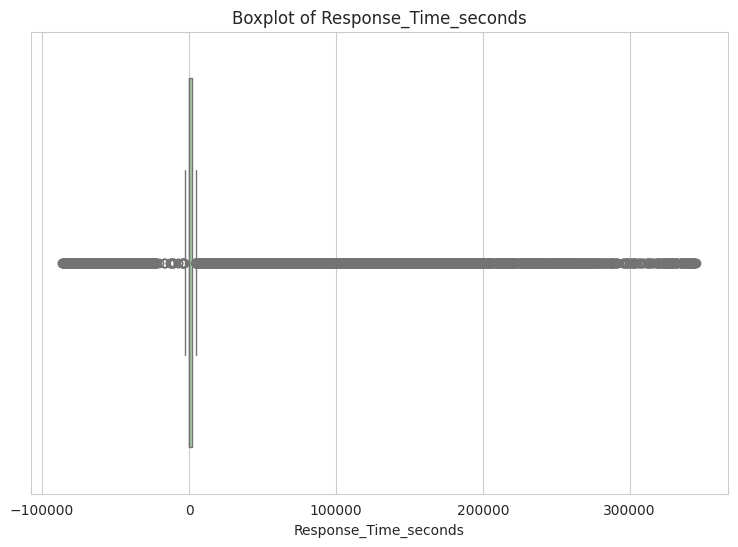

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns (excluding Has_handling_time)
numeric_cols = final_df1.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'has_handling_time']

# Histogram + KDE for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(9, 6))
    feature = final_df1[col]

    # Histogram with KDE
    sns.histplot(feature, kde=True, color="skyblue")

    # Mean and Median Lines
    plt.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2, label=f"Mean: {feature.mean():.2f}")
    plt.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2, label=f"Median: {feature.median():.2f}")

    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.show()

# Boxplots for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(9, 6))
    sns.boxplot(x=final_df1[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")
    plt.show()


## 1. Why did you choose the specific chart?

I chose a histogram because it’s an effective tool for summarising and visualising data distribution. It helps identify the overall shape of the distribution (symmetric, skewed, or irregular), unusual observations (outliers) or gaps in data, and frequency patterns, especially when working with large datasets (over 100 observations).

For this reason, I used histograms to analyse variable distributions across the dataset and assess their symmetry.

On the other hand, a box plot is designed to provide a concise summary of numerical data. It displays the minimum, maximum, median, quartiles, and potential outliers. This high-level view of variance, spread, and symmetry makes it ideal for detecting outliers and understanding data ranges quickly.

Therefore, for each numerical variable, I used both histograms and box plots together to capture both overall distribution patterns and specific details such as outliers, interquartile ranges, and summary statistics.

—

## 2. What insights were gained from the charts?

* The “Connected Handling Time” feature has a symmetric distribution, with the mean closely aligned with the median. This indicates relatively balanced data without significant skewness.
* The “Item Price” feature, however, shows a skewed distribution with noise or outliers. This suggests irregularities in data quality or variations that may need further investigation, such as incorrect entries, extreme values, or genuine high-value items.

—

## 3. Will the gained insights help create a positive business impact?

While these initial charts don’t directly provide business impact, they form a crucial foundation for further analysis. Understanding data distributions ensures that subsequent modelling or decision-making is based on reliable data.

Histograms and box plots can be powerful tools for data analysis, providing insights into data quality and enabling informed decision-making. 

**Positive contribution**: By detecting outliers and skewness early, histograms and box plots help in cleaning and preparing data, leading to more accurate models and insights. For instance, correcting noisy “Item Price” values can improve revenue, pricing, and forecasting analysis.

**Negative implications**: If ignored, skewed distributions or unaddressed outliers could mislead business decisions, resulting in inaccurate demand forecasts, inefficient operations, or misaligned strategies.

In summary, while histograms and box plots themselves don’t deliver direct business outcomes, they enable better data quality checks and informed decision-making, ultimately supporting positive business impact.



#### Chart - 5 - Correlation Heatmap

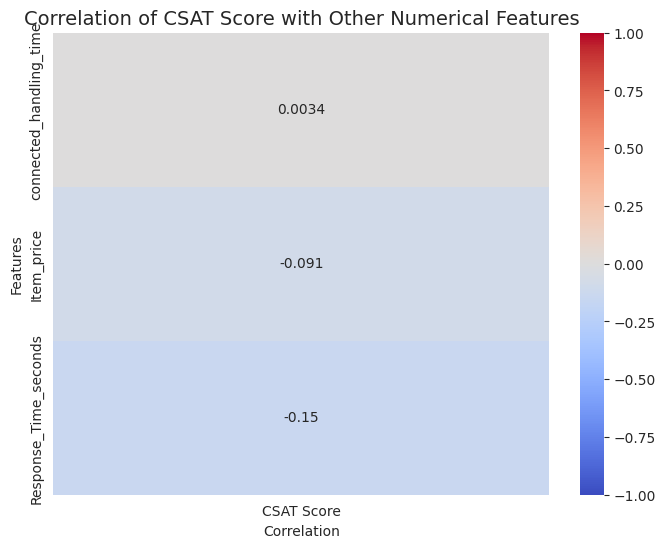

In [ ]:
# Calculate correlation matrix for numerical features
correlation_matrix = final_df1.corr(numeric_only=True)

# Define target variable
target_variable = 'CSAT Score'

# Extract correlation of target with other features
correlation_with_target = (
    correlation_matrix[[target_variable]]
    .drop(index=target_variable)  # remove self-correlation
    .sort_values(by=target_variable, ascending=False)
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_with_target,
    annot=True,
    cmap='coolwarm',
    cbar=True,
    vmin=-1, vmax=1
)
plt.title(f'Correlation of {target_variable} with Other Numerical Features', fontsize=14)
plt.ylabel("Features")
plt.xlabel("Correlation")
plt.show()

### **Chart - 6 - Pair Plot**

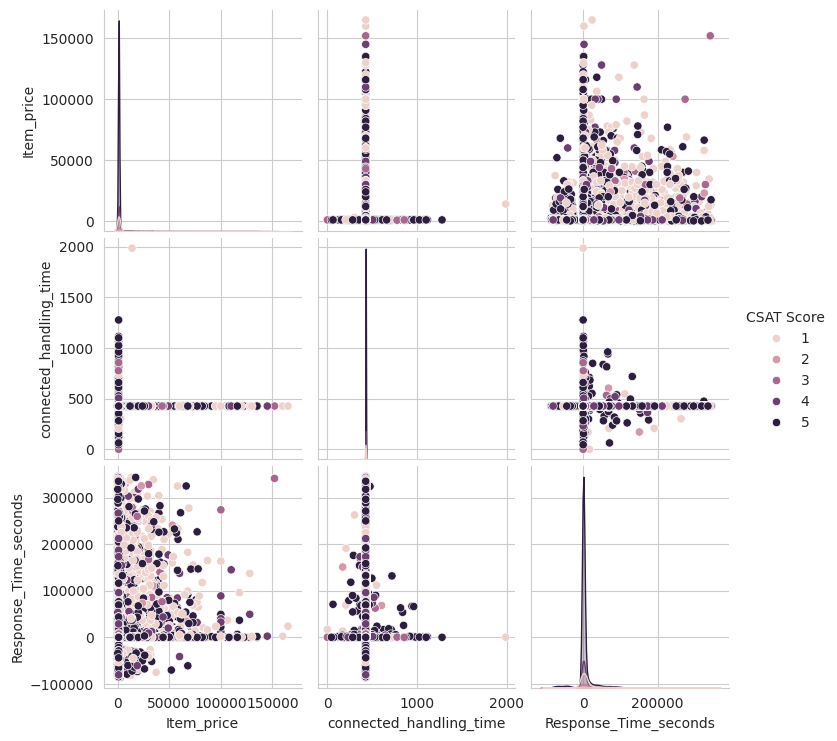

In [ ]:
# Pair Plot visualization code
sns.pairplot(final_df1, hue="CSAT Score")

### 1. Why did you choose the specific chart?

I selected a pair plot because it effectively visualises the relationships between multiple features simultaneously. It demonstrates how two variables are connected and whether they form distinct clusters or separations. This makes it ideal for identifying patterns, potential correlations, or even constructing basic classification models with linear boundaries.

In contrast to a correlation map, a pair plot provides a graphical representation, making it easier to visually identify trends, clusters, or overlaps in the data.

### 2. What insights were gained from the chart?

From the pair plot, I observed the following:

* Most variables lack strong linear relationships, and the data points are not linearly separable.
* Customer feedback data appears to be clustered but also overlaps across features.
* Connected handling time exhibits a fairly symmetrical distribution.
* Item price and response time are more skewed (non-symmetric) in nature.
* Among all features, response time emerges as a crucial factor.
* The relationship between connected handling time and other features offers valuable insights into customer interactions.

Overall, the pair plot underscores the complexity and overlaps in the data, suggesting that simple linear separation may not fully capture the underlying patterns.




In [ ]:
final_df1.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'Response_Time', 'Response_Time_seconds'],
      dtype='object')

In [ ]:
final_df1['Tenure Bucket'].value_counts()

,count
Tenure Bucket,
>90,30660
On Job Training,25523
31-60,11665
0-30,11318
61-90,6741


## ***5. Outlier Detection and Removal***

### **Step 1: Treat Categorical Columns Properly**

CSAT Score is categorical (only 1–5), so we convert it to string.

In [ ]:
final_df1['CSAT Score'] = final_df1['CSAT Score'].astype(str)

In [ ]:
final_df1.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'Response_Time', 'Response_Time_seconds'],
      dtype='object')

In [ ]:
final_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Unique id                85907 non-null  object         
 1   channel_name             85907 non-null  object         
 2   category                 85907 non-null  object         
 3   Sub-category             85907 non-null  object         
 4   Customer Remarks         85907 non-null  object         
 5   order_date_time          85907 non-null  datetime64[ns] 
 6   Issue_reported at        85907 non-null  datetime64[ns] 
 7   issue_responded          85907 non-null  datetime64[ns] 
 8   Survey_response_Date     85907 non-null  object         
 9   Customer_City            85907 non-null  object         
 10  Product_category         85907 non-null  object         
 11  Item_price               85907 non-null  float64        
 12  connected_handling

### **Step 2: Separate Symmetric and Skewed Features**

Symmetric: mean ≈ median → can use IQR or std-based outlier treatment

Skewed: mean far from median → use mean ± 3*std

In [ ]:
import numpy as np

symmetric_features = []
skewed_features = []

# Select only numeric columns, exclude timedelta and object
numeric_cols = final_df1.select_dtypes(include=['int64', 'float64']).columns

# Drop identifier column if present
numeric_cols = numeric_cols.drop('Unique id', errors='ignore')

# Loop through numeric features
for col in numeric_cols:
    mean_val = final_df1[col].mean()
    median_val = final_df1[col].median()

    # Use relative difference between mean and median
    if abs(mean_val - median_val) / (abs(median_val) + 1e-9) < 0.2:
        symmetric_features.append(col)
    else:
        skewed_features.append(col)

print("✅ Symmetric Distributed Features:", symmetric_features)
print("✅ Skewed Distributed Features:", skewed_features)


✅ Symmetric Distributed Features: ['connected_handling_time']
✅ Skewed Distributed Features: ['Item_price', 'Response_Time_seconds']


### *Step 3: Outlier Treatment*


### **3a: Symmetric Features (IQR Method)**

In [ ]:
for feature in symmetric_features:
    Q1 = final_df1[feature].quantile(0.25)
    Q3 = final_df1[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    final_df1.loc[final_df1[feature] < lower_bound, feature] = lower_bound
    final_df1.loc[final_df1[feature] > upper_bound, feature] = upper_bound

### **3b: Skewed Features (Mean ± 3×STD)**

In [ ]:
def outlier_treatment(df, feature):
    upper = df[feature].mean() + 3 * df[feature].std()
    lower = df[feature].mean() - 3 * df[feature].std()
    return upper, lower

for feature in skewed_features:
    upper, lower = outlier_treatment(final_df1, feature)
    final_df1.loc[final_df1[feature] > upper, feature] = upper
    final_df1.loc[final_df1[feature] < lower, feature] = lower

### **Step 4: Visualize Outliers After Treatment**

Use strip plots to see the distribution

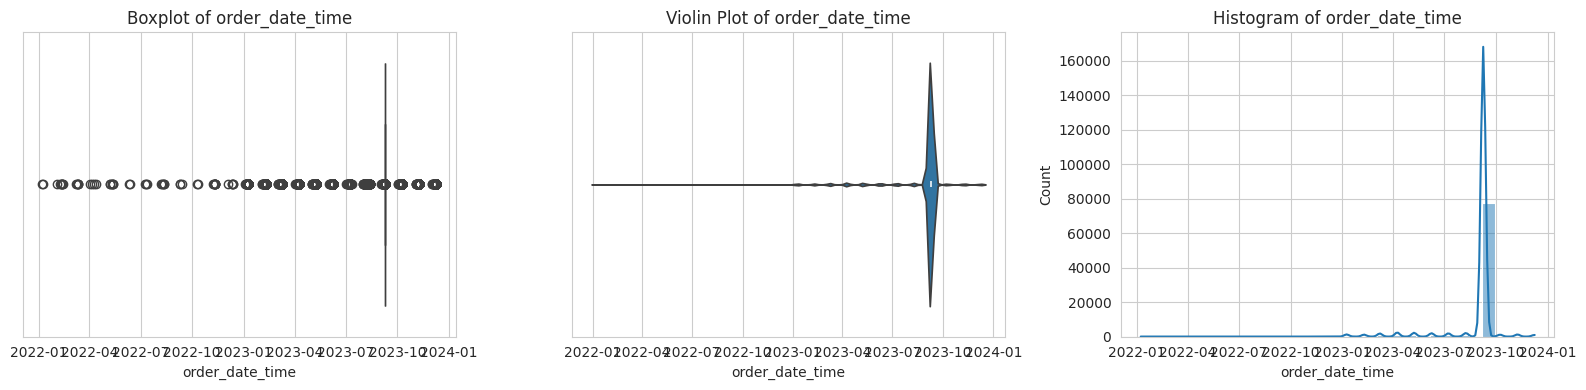

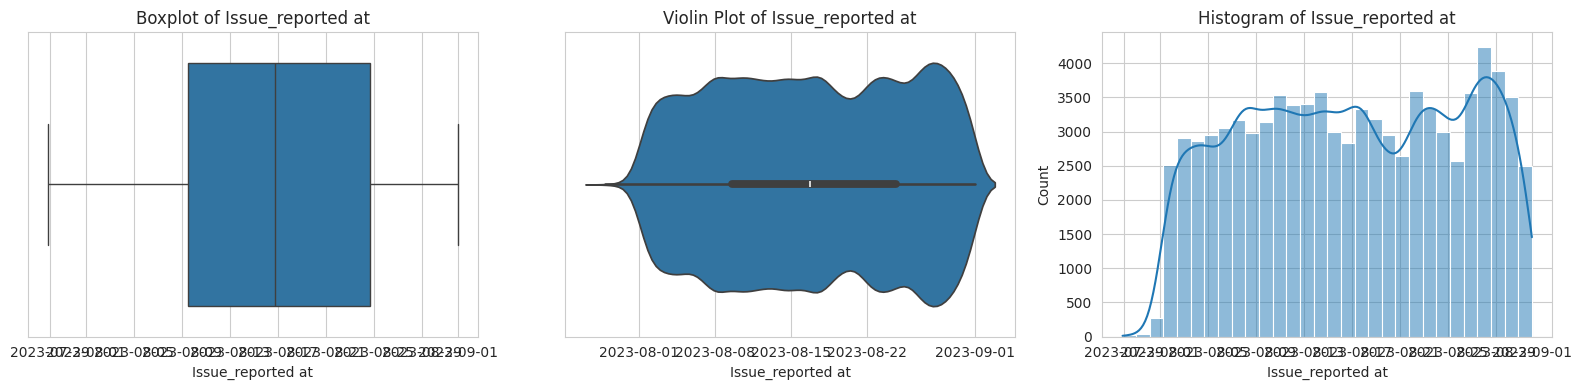

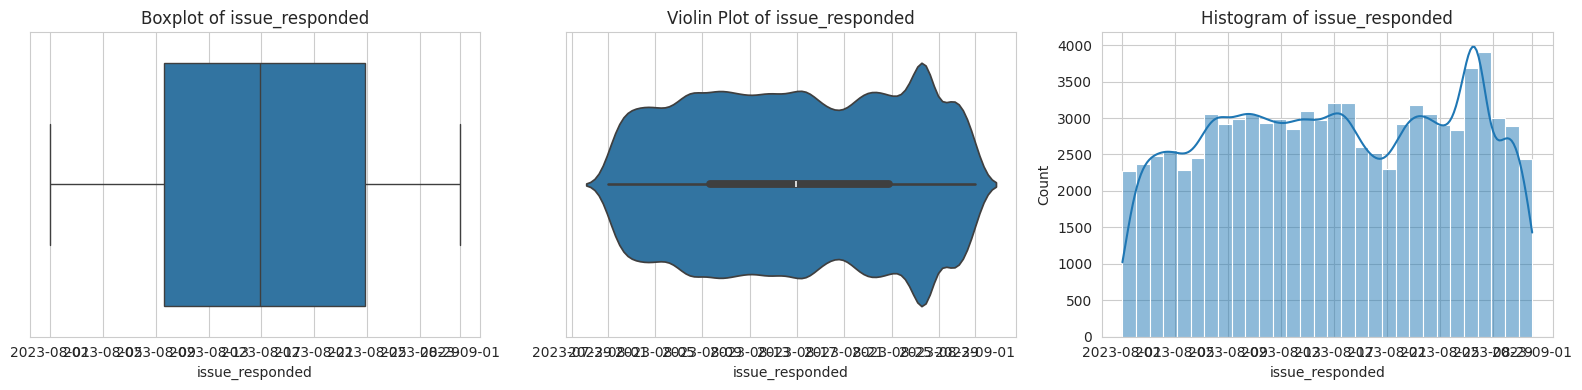

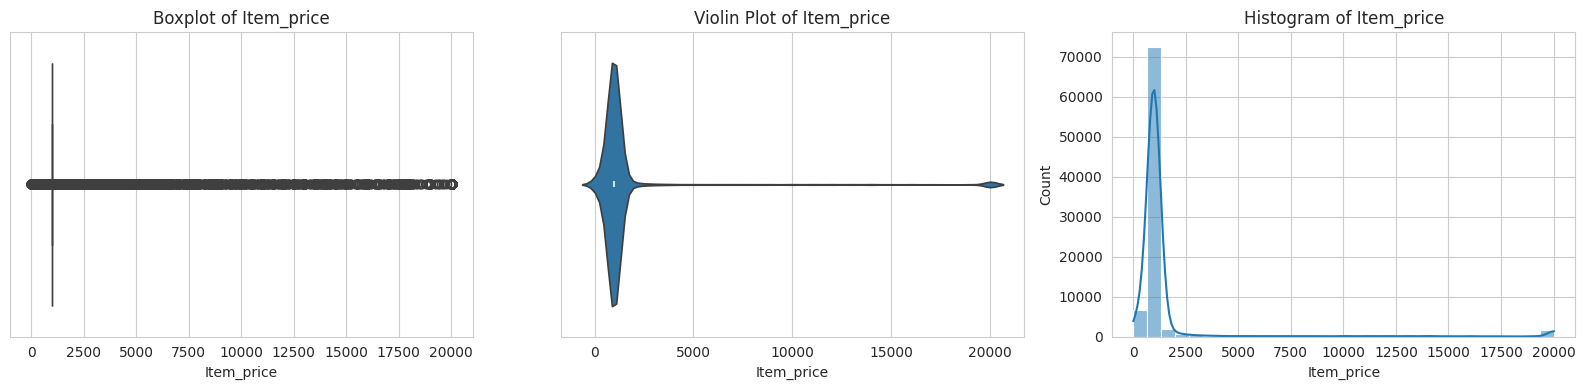

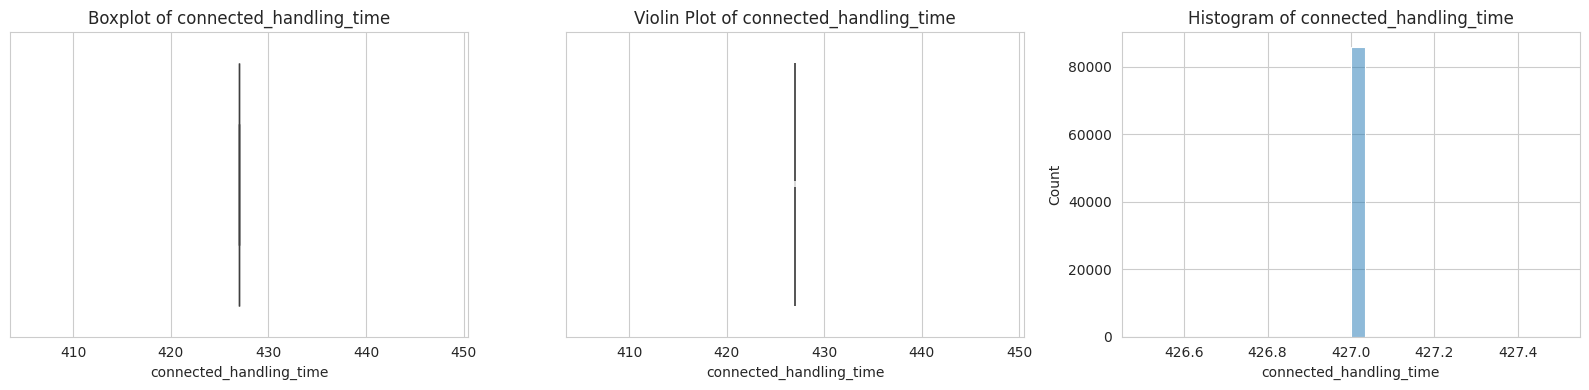

⚠️ Skipping column Response_Time due to MemoryError


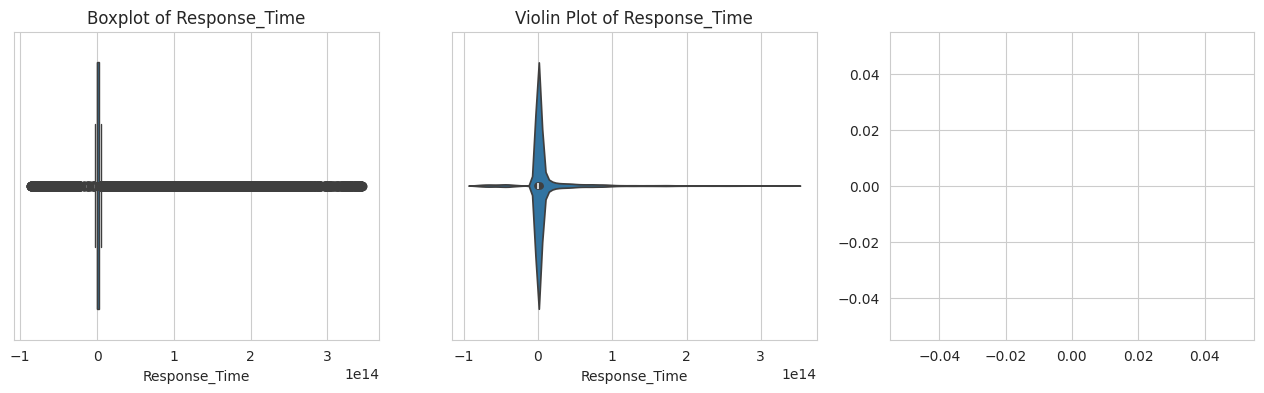

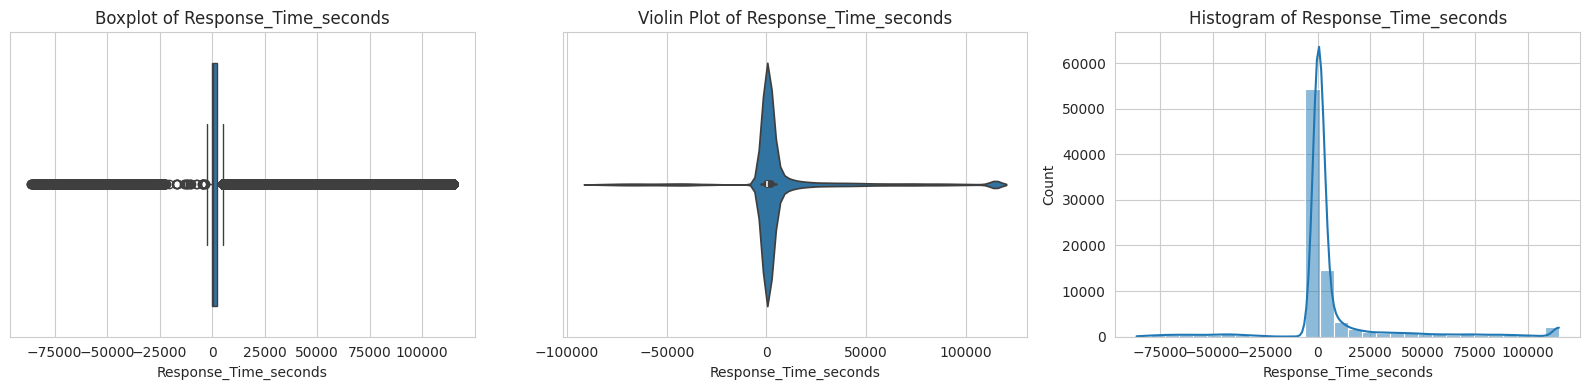

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop safely over numeric columns
for col in final_df1.describe().columns:
    try:
        plt.figure(figsize=(16,4))

        plt.subplot(1,3,1)
        sns.boxplot(x=final_df1[col])
        plt.title(f'Boxplot of {col}')

        plt.subplot(1,3,2)
        sns.violinplot(x=final_df1[col])
        plt.title(f'Violin Plot of {col}')

        plt.subplot(1,3,3)
        sns.histplot(final_df1[col], bins=30, kde=True)
        plt.title(f'Histogram of {col}')

        plt.tight_layout()
        plt.show()
    except MemoryError:
        print(f"⚠️ Skipping column {col} due to MemoryError")
    except Exception as e:
        print(f"⚠️ Skipping column {col} due to error: {e}")

### ***Conclusion***

The CSAT Score is treated as categorical, so it’s not affected by numeric outlier treatment.

Symmetric features have outliers capped using the IQR method, ensuring extreme values don’t distort the model.

Skewed features have outliers capped using the mean ± 3×std, reducing the impact of extreme high/low values while preserving most data points.

Visualisations, including boxplots, violin plots, and histograms, show that extreme outliers have been properly restricted, resulting in cleaner distributions.

Overall, this approach balances data integrity and model stability, making the dataset ready for further analysis or modelling.

## *6. Feature Engineering*

## **1. Categorical Encoding**

In [ ]:
final_df2=final_df1.copy()

### **Step 1:- Drop Unnecessary Column**

In [ ]:
final_df2.drop(columns=['Unique id'], inplace=True)

### **Step 2:- Convert Target columna**

In [ ]:
final_df2["CSAT Score"] = final_df2["CSAT Score"].astype(int)

### **Step 3: Handle datetime columns**

In [ ]:
datetime_cols = ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']

for col in datetime_cols:
    final_df2[col] = pd.to_datetime(final_df2[col], errors='coerce')
    final_df2[col + '_day'] = final_df2[col].dt.day
    final_df2[col + '_month'] = final_df2[col].dt.month
    final_df2[col + '_hour'] = final_df2[col].dt.hour
    final_df2[col + '_weekday'] = final_df2[col].dt.weekday

# Optionally drop original datetime cols
final_df2.drop(columns=datetime_cols, inplace=True)

### **Step 4: Define categorical columns**

Low cardinality → one-hot encoding

High cardinality → label encoding

In [ ]:
low_cardinality = ['channel_name','category','Sub-category',
                   'Tenure Bucket','Agent Shift','Product_category','Customer_City']

high_cardinality = ['Agent_name','Supervisor','Manager']

### **Step 5: One-hot encode low-cardinality categoricals**

In [ ]:
final_df2 = pd.get_dummies(final_df2, columns=low_cardinality, drop_first=True)

### **Step 6: Label encode high-cardinality categoricals**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in high_cardinality:
    final_df2[col] = le.fit_transform(final_df2[col].astype(str))

In [ ]:
final_df3=final_df2.copy()

### **Step 7 :- Frequency Encoding for Customer City**

In [ ]:
# city_freq = final_df3['Customer_City'].value_counts()
# final_df3['Customer_City_FE'] = final_df3['Customer_City'].map(city_freq)

In [ ]:
final_df3=final_df2.copy()

### **Step 8 : Text Feature Encoding using TF-IDF**

Since Customer Remarks is a free-text, high-cardinality feature, we couldn’t directly apply one-hot or label encoding. Instead, we used TF-IDF (Term Frequency–Inverse Document Frequency) to transform the text into numerical vectors, based on how important each word is in the corpus.

We then extracted the top 100 keywords and created new features representing the weight of each keyword in the remarks. This made the text data usable for machine learning models.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=100)  
remarks_tfidf = tfidf.fit_transform(final_df3['Customer Remarks'])
remarks_df = pd.DataFrame(remarks_tfidf.toarray(), columns=tfidf.get_feature_names_out())
final_df3 = pd.concat([final_df3.reset_index(drop=True), remarks_df.reset_index(drop=True)], axis=1)

In [ ]:
final_df3.columns

Index(['Customer Remarks', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'CSAT Score', 'Response_Time',
       'Response_Time_seconds', 'Customer_Type',
       ...
       'to', 'very', 'was', 'we', 'will', 'with', 'work', 'worst', 'you',
       'your'],
      dtype='object', length=1992)

## **2. Feature Manipulation**

In [ ]:
df_encoded=final_df3.copy()

In [ ]:
# Convert Response_Time to total seconds (numeric)
df_encoded['Response_Time_seconds'] = df_encoded['Response_Time'].dt.total_seconds()

In [ ]:
# Checking the shape of dataset
df_encoded.shape

(85907, 1992)

In [ ]:
df_encoded.drop(columns=['Customer Remarks','Response_Time'],inplace=True)

In [ ]:
df_encoded.columns

Index(['Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'CSAT Score', 'Response_Time_seconds', 'Customer_Type',
       'order_date_time_day', 'order_date_time_month',
       ...
       'to', 'very', 'was', 'we', 'will', 'with', 'work', 'worst', 'you',
       'your'],
      dtype='object', length=1990)

## **3.Feature Selection**

### **Step 1: Dropping Constant & Quasi-Constant Features**

This feature selection removes features with very low variance (<0.05), as they don’t vary much and won’t contribute to prediction. It also ensures that the CSAT Score is never dropped.

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Columns: 1990 entries, Item_price to your
dtypes: bool(1866), float64(103), int32(16), int64(4), object(1)
memory usage: 228.9+ MB


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Select only numeric data
numeric_data = df_encoded.select_dtypes(include=['number'])

# Apply VarianceThreshold
var_thres = VarianceThreshold(threshold=0.05)
var_thres.fit(numeric_data)

# Columns that were kept
kept_cols = numeric_data.columns[var_thres.get_support()]

# Columns that were dropped (low variance)
dropped_cols = [col for col in numeric_data.columns if col not in kept_cols]

# Remove target if mistakenly added
if "CSAT Score" in dropped_cols:
    dropped_cols.remove("CSAT Score")

print("Number of low variance columns dropped:", len(dropped_cols))
print("Dropped columns:")
print(dropped_cols)


Number of low variance columns dropped: 104
Dropped columns:
['connected_handling_time', 'Issue_reported at_month', 'issue_responded_month', 'Survey_response_Date_month', 'Survey_response_Date_hour', 'after', 'agent', 'all', 'also', 'am', 'and', 'any', 'are', 'as', 'bad', 'be', 'behaviour', 'best', 'but', 'by', 'call', 'can', 'care', 'customer', 'customers', 'delivered', 'delivery', 'do', 'don', 'excellent', 'executive', 'experience', 'for', 'from', 'give', 'happy', 'has', 'have', 'he', 'help', 'helpful', 'if', 'in', 'information', 'is', 'issue', 'it', 'like', 'make', 'me', 'more', 'much', 'my', 'need', 'nice', 'no', 'not', 'of', 'ok', 'on', 'one', 'or', 'order', 'person', 'please', 'policy', 'poor', 'problem', 'product', 'products', 'provide', 'refund', 'resolve', 'resolved', 'return', 'service', 'she', 'shopzilla', 'should', 'sir', 'so', 'solve', 'solved', 'support', 'talk', 'team', 'thank', 'thanks', 'that', 'the', 'there', 'they', 'this', 'time', 'to', 'very', 'was', 'we', 'will', 

In [ ]:
from sklearn.feature_selection import VarianceThreshold

def dropping_constant(data):
    numeric_data = data.select_dtypes(include=['number'])
    var_thres = VarianceThreshold(threshold=0.05)  # remove near-constant features
    var_thres.fit(numeric_data)

    concol = [column for column in numeric_data.columns
              if column not in numeric_data.columns[var_thres.get_support()]]
    if "CSAT Score" in concol:
        concol.remove("CSAT Score")

    df_removed_var = data.drop(concol, axis=1)
    return df_removed_var

df_removed_var = dropping_constant(df_encoded)


In [ ]:
df_removed_var.shape

(85907, 1886)

### **Step 2 : Check Multicollinearity (VIF)**

A VIF (Variance Inflation Factor) of 5 (or 10) indicates high multicollinearity. 

Highly collinear features can be dropped to reduce redundancy and improve model stability.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_data = df_removed_var.select_dtypes(include=['number'])
numeric_data.drop(columns=['CSAT Score'], inplace=True)

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

vif_results = calculate_vif(numeric_data)
print(vif_results)

                         Feature         VIF
0                     Item_price    1.313938
1                     Agent_name    4.033328
2                     Supervisor    3.690024
3                        Manager    3.110146
4          Response_Time_seconds    1.101077
5            order_date_time_day  139.453328
6          order_date_time_month   50.800141
7           order_date_time_hour   28.685789
8        order_date_time_weekday   36.712652
9          Issue_reported at_day  129.842117
10        Issue_reported at_hour   16.575414
11     Issue_reported at_weekday   19.664695
12           issue_responded_day         inf
13          issue_responded_hour   12.313812
14       issue_responded_weekday         inf
15      Survey_response_Date_day         inf
16  Survey_response_Date_weekday         inf
17                          good    3.644591


### **Step 3: Correlation Heatmap & Highly Correlated Feature Removal**

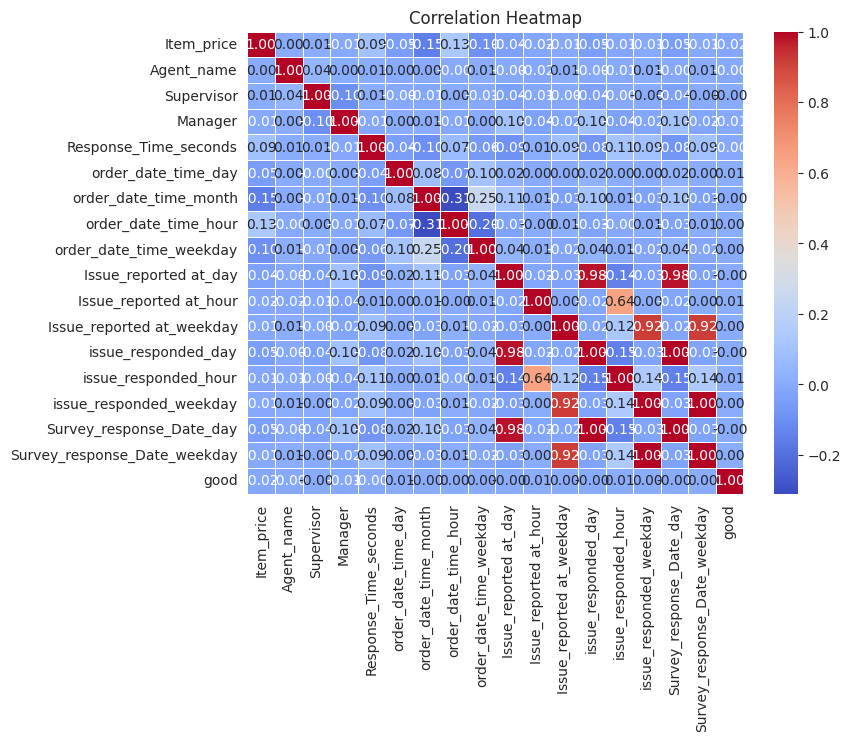

In [ ]:
corr = numeric_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Drop features with correlation > 0.5
def correlation(df, threshold):
    col_corr = set()
    corr_matrix = df.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return list(col_corr)

highly_correlated_columns = correlation(numeric_data, 0.5)
df_removed = df_removed_var.drop(highly_correlated_columns, axis=1)

### **Step 4: Check VIF Again After Dropping**

In [ ]:
numeric_data = df_removed.select_dtypes(include=['number'])
numeric_data.drop(columns=['CSAT Score'], inplace=True)
vif_results = calculate_vif(numeric_data)
print(vif_results)

                      Feature         VIF
0                  Item_price    1.312552
1                  Agent_name    4.033235
2                  Supervisor    3.690017
3                     Manager    3.109236
4       Response_Time_seconds    1.084765
5         order_date_time_day  139.029079
6       order_date_time_month   50.735373
7        order_date_time_hour   28.682508
8     order_date_time_weekday   36.709394
9       Issue_reported at_day    4.582804
10     Issue_reported at_hour    9.461482
11  Issue_reported at_weekday    3.134330
12                       good    3.644566


In [ ]:
df_removed.shape

(85907, 1881)

In [ ]:
cols_to_drop = ['order_date_time_day', 'order_date_time_month','order_date_time_weekday']
df_removed.drop(columns=cols_to_drop, inplace=True)

In [ ]:
df_removed.isnull().sum()

,0
Item_price,0
Agent_name,0
Supervisor,0
Manager,0
CSAT Score,0
...,...
Customer_City_ZAMANIA,0
Customer_City_ZIRA,0
Customer_City_ZIRAKPUR,0
Customer_City_ZUARINAGAR,0


## **4. Data Transformation and Handling Skewed Features**

**Identify Symmetric vs Skewed Features**

To determine if a feature is symmetric or skewed, we calculated the absolute difference between its mean and median. Features with a difference less than 0.25 are considered symmetric, while those with a difference greater than or equal to 0.25 are skewed.

Skewed features often negatively impact model performance, while symmetric features are already well-behaved.

**Apply Transformations to Reduce Skew**

To address skewed features, we applied square root (np.sqrt) or 0.25th power transformation. These transformations help make the distributions more symmetric.

For example, we transformed Item_price to sqrt and Response_Time_seconds to sqrt. We also transformed day_number_order_date and day_number_response_date to 0.25th power.

**Iterative Checking**

After each transformation, we recalculated the symmetric vs skewed features to confirm that the transformations had improved the distribution.

**Visualisation**

We plotted histograms (sns.distplot) with mean and median lines to visually check the distribution of the transformed features.

**Important Notes**

We excluded CSAT Score from the skew/symmetric checks because it is the target variable.

We only transformed numeric predictive features; categorical features and encoding were retained as-is.

**Outcome:**

Skewed numeric features were transformed to be closer to symmetric distributions.

As a result, the neural network will have better convergence and improved performance on the transformed inputs.

In [ ]:
df_removed.columns

Index(['Item_price', 'Agent_name', 'Supervisor', 'Manager', 'CSAT Score',
       'Response_Time_seconds', 'Customer_Type', 'order_date_time_hour',
       'Issue_reported at_day', 'Issue_reported at_hour',
       ...
       'Customer_City_YELESWARAM', 'Customer_City_YEOTAMAL',
       'Customer_City_YERRAGUNTLA', 'Customer_City_Yeola',
       'Customer_City_ZAHEERABAD', 'Customer_City_ZAMANIA',
       'Customer_City_ZIRA', 'Customer_City_ZIRAKPUR',
       'Customer_City_ZUARINAGAR', 'good'],
      dtype='object', length=1878)

Symmetric features after transformation: ['Item_price', 'order_date_time_hour', 'Issue_reported at_weekday', 'Issue_reported at_hour', 'Issue_reported at_day']
Skewed features after transformation: ['Response_Time_seconds']


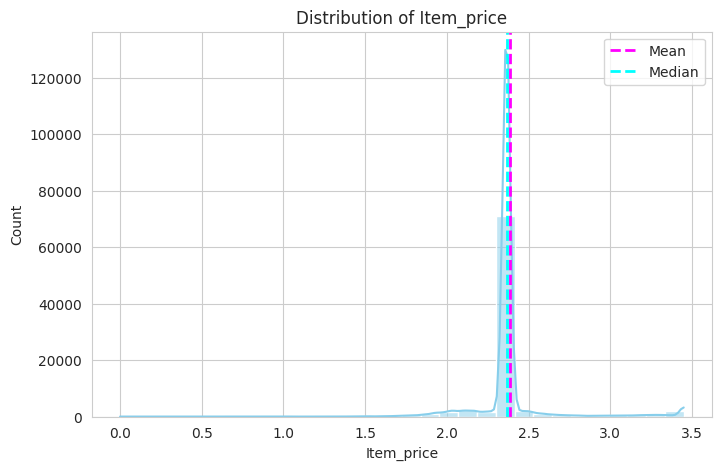

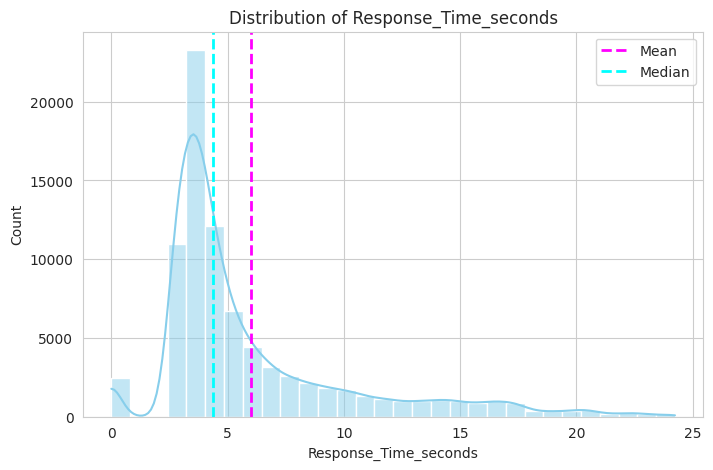

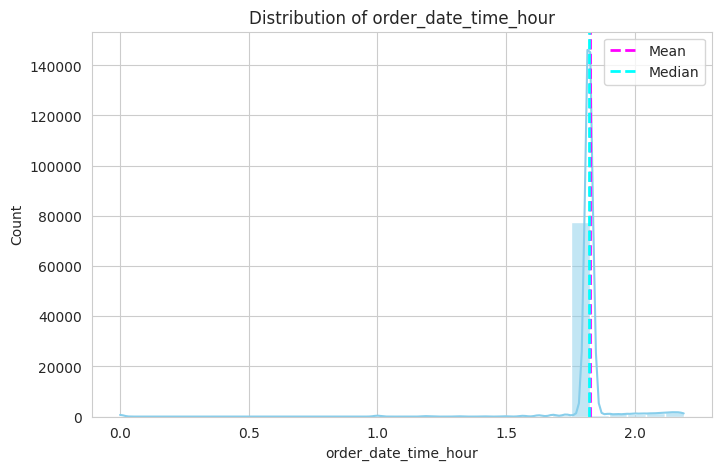

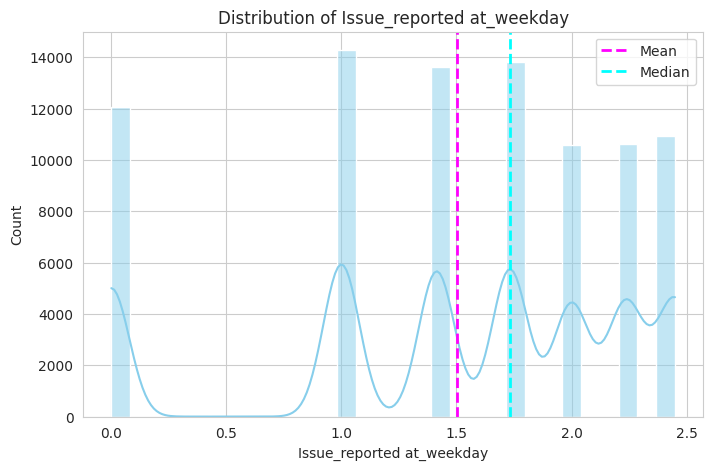

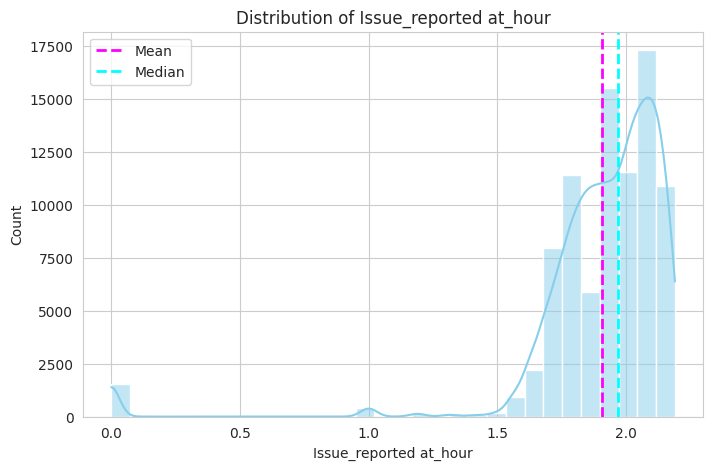

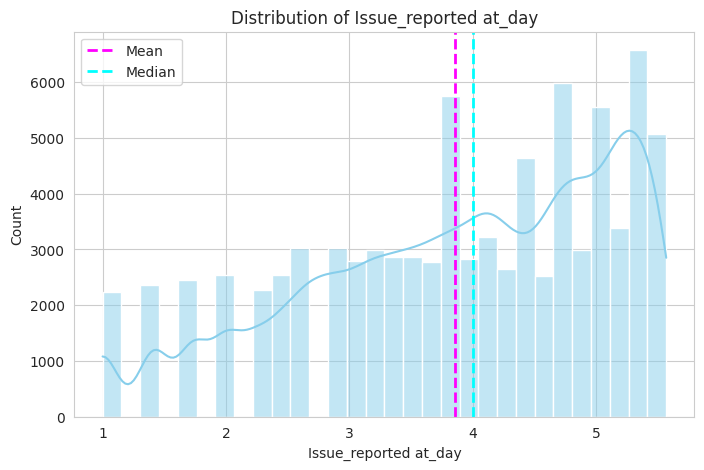

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 1️⃣ Continuous numeric features
# =============================
continuous_features = [
    'Item_price',
    'Response_Time_seconds',
    'order_date_time_hour',
    'Issue_reported at_weekday','Issue_reported at_hour', 'Issue_reported at_day'
]

# =============================
# 2️⃣ Iterative transformations to reduce skew
# =============================
def transform_numeric_features(df, features):
    df_transformed = df.copy()
    for col in features:
        # Apply 0.25th power for heavy skewed features
        if col == 'Item_price':
            df_transformed[col] = df_transformed[col] ** 0.25
        # Apply sqrt transformation to moderate skew
        else:
            df_transformed[col] = np.sqrt(df_transformed[col])

        # Optional: apply one more sqrt if still skewed
        if abs(df_transformed[col].skew()) > 1:
            df_transformed[col] = np.sqrt(df_transformed[col])
    return df_transformed

df_transformed = transform_numeric_features(df_removed, continuous_features)

# =============================
# 3️⃣ Check symmetry vs skew
# =============================
def check_symmetry(df, features, threshold=0.25):
    symmetric = []
    skewed = []
    for col in features:
        if abs(df[col].mean() - df[col].median()) < threshold:
            symmetric.append(col)
        else:
            skewed.append(col)
    return symmetric, skewed

symmetric_features, skewed_features = check_symmetry(df_transformed, continuous_features)
print("Symmetric features after transformation:", symmetric_features)
print("Skewed features after transformation:", skewed_features)

# =============================
# 4️⃣ Visualize distributions
# =============================
def plot_distributions(df, features):
    for col in features:
        plt.figure(figsize=(8,5))
        sns.histplot(df[col], kde=True, bins=30, color='skyblue')
        plt.axvline(df[col].mean(), color='magenta', linestyle='dashed', linewidth=2, label='Mean')
        plt.axvline(df[col].median(), color='cyan', linestyle='dashed', linewidth=2, label='Median')
        plt.title(f'Distribution of {col}')
        plt.legend()
        plt.show()

plot_distributions(df_transformed, continuous_features)


## **5.Data Scaling**

To ensure equal contribution of features during model training, standardisation was applied to the selected continuous numerical variables: `Item_price`, `Response_Time_seconds`, `Issue_reported at_day`, and `Issue_reported at_hour`. These features were transformed using `StandardScaler`, which rescales values to have a mean of 0 and a standard deviation of 1.

The choice of `StandardScaler` was made because the numerical features approximately follow a Gaussian (normal) distribution, making standardisation more appropriate. Unlike `MinMaxScaler`, which scales values to a fixed range (0–1) and can be sensitive to outliers, `StandardScaler` preserves the distribution shape and handles outliers better for normally distributed data.

Categorical features encoded through `One-Hot Encoding` or `Label Encoding` were excluded from scaling as they are already in a machine-learning-friendly format. The fitted scaler was saved (`scaler.pkl`) to maintain consistency during future predictions and deployment.



In [ ]:
# Make a copy of your transformed dataset
final_df = df_transformed.copy()

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Columns: 1878 entries, Item_price to good
dtypes: bool(1866), float64(7), int64(4), object(1)
memory usage: 160.7+ MB


In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler


# Separate target variable
y = final_df['CSAT Score']
X = final_df.drop(columns=['CSAT Score'])


# Select only continuous numeric columns for scaling
continuous_features = [
    'Item_price',
    'Response_Time_seconds',
    'order_date_time_hour',
    'Issue_reported at_weekday','Issue_reported at_hour', 'Issue_reported at_day'
]

# Initialize the scaler
scaler = StandardScaler()

# Apply scaling only on continuous features
X[continuous_features] = scaler.fit_transform(X[continuous_features])

# Save the fitted scaler for later use (important if you’ll deploy the model)
joblib.dump(scaler, "scaler.pkl")

# Combine scaled X with target back if needed
df_scaled = X.copy()
df_scaled['CSAT Score'] = y

# Preview final scaled dataset
print(df_scaled.head())


   Item_price  Agent_name  Supervisor  Manager  Response_Time_seconds  \
0    -0.09226        1072          26        1               0.168081   
1    -0.09226        1323           9        3              -0.624787   
2    -0.09226         370          18        5               0.006988   
3    -0.09226        1024          33        2              -0.026003   
4    -0.09226         247           4        3              -0.624787   

  Customer_Type  order_date_time_hour  Issue_reported at_day  \
0           New              -0.02739              -2.326293   
1     Returning              -0.02739              -2.326293   
2           New              -0.02739              -2.326293   
3     Returning              -0.02739              -2.326293   
4           New              -0.02739              -2.326293   

   Issue_reported at_hour  Issue_reported at_weekday  ...  \
0               -0.277868                  -0.661443  ...   
1               -0.148142                  -0.661443  

## **6. Data Splitting**

To assess model performance on unseen data, the dataset was divided into a **training (70%) and testing (30%)** subsets. The target variable, CSAT (0–5 rating), was transformed using **One-Hot Encoding** to represent it as multiple classes suitable for deep learning models.

Furthermore, the **feature list** was saved (`features.pkl`) to preserve the exact column order for future predictions and deployment. This ensures consistency and reproducibility of the pipeline.  



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import joblib


# 1️⃣ Separate features and target

X = df_transformed.drop(columns=['CSAT Score'])
y = df_transformed['CSAT Score'].values.reshape(-1, 1)


# 2️⃣ One-Hot Encode the target

encoder = OneHotEncoder(sparse_output=False)
y_one_hot = encoder.fit_transform(y)

# Convert encoded target into DataFrame
y_one_hot_df = pd.DataFrame(
    y_one_hot,
    columns=[f'class_{int(i)}' for i in range(y_one_hot.shape[1])]
)


# 3️⃣ Train-Test Split (70:30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_one_hot_df, test_size=0.3, random_state=0, stratify=y
)


# 4️⃣ Save Feature List & Encoder

features_list = X_train.columns.to_list()
joblib.dump(features_list, "features.pkl")
joblib.dump(encoder, "target_encoder.pkl")


# 5️⃣ Print Dataset Shapes

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60134, 1877)
y_train shape: (60134, 5)
X_test shape: (25773, 1877)
y_test shape: (25773, 5)


In [ ]:

# Save Feature List

features_list = X_train.columns.to_list()

# Save feature list using joblib
import joblib
joblib.dump(features_list, "features.pkl")

print("Feature list saved successfully! Total features:", len(features_list))

Feature list saved successfully! Total features: 1877


## **7. Handling Data Imbalance**

To address the imbalance in the target variable (`CSAT Score`), the SMOTE (Synthetic Minority Over-sampling Technique) algorithm was applied to the training dataset. SMOTE generates synthetic samples for minority classes, balancing the distribution and preventing the model from becoming biased towards the majority class.

Before applying SMOTE, missing values in numerical features (`Response_Time_seconds`, `Item_price`, `Issue_reported at_day`, `Issue_reported at_hour`) were handled using median imputation. This step ensures that the resampling process doesn’t encounter errors due to `NaN` values while preserving the original data’s distribution.

After resampling, the target variable was one-hot encoded to ensure compatibility with multi-class classification models. Finally, a bar chart visualisation confirms that the resampled training dataset now has a balanced class distribution.





Step 1: Convert One-Hot Target to Integer Labels

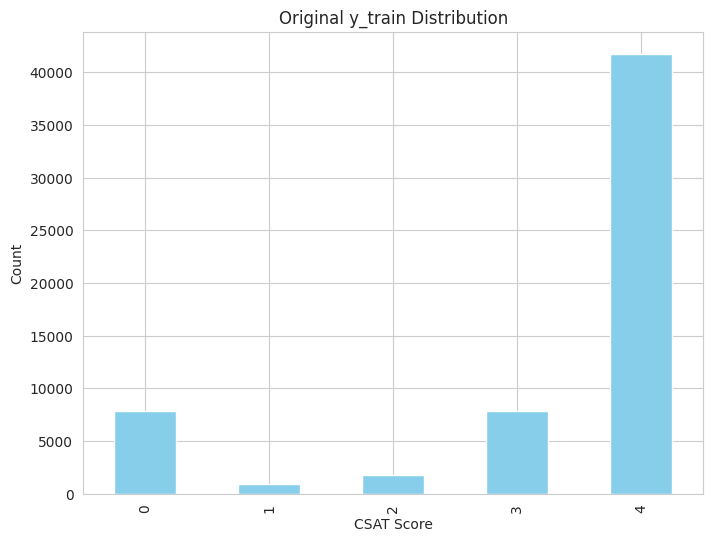

In [ ]:
# Convert one-hot encoded y_train back to integer labels for SMOTE
y_series = y_train.idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))

# Visualize the original distribution
plt.figure(figsize=(8,6))
y_series.value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Original y_train Distribution")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()

In [ ]:
# Check for missing values in training data
missing_counts = X_train.isna().sum()
print(missing_counts[missing_counts > 0])

Response_Time_seconds    2196
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer

# Impute numerical columns with median
num_cols = ['Item_price', 'Response_Time_seconds', 'Issue_reported at_day', 'Issue_reported at_hour']
imputer = SimpleImputer(strategy='median')

X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])  

In [ ]:
df_removed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Columns: 1878 entries, Item_price to good
dtypes: bool(1866), float64(3), int32(4), int64(4), object(1)
memory usage: 159.4+ MB


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder


# 1️⃣ Encode categorical columns

cat_cols = X_train.select_dtypes(include=['object']).columns

if len(cat_cols) > 0:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

    # Fit on train, transform both train & test
    X_train_encoded = encoder.fit_transform(X_train[cat_cols])
    X_test_encoded = encoder.transform(X_test[cat_cols])

    # Convert back to DataFrames with feature names
    encoded_cols = encoder.get_feature_names_out(cat_cols)
    X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
    X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

    # Drop original categorical cols and concat encoded ones
    X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_encoded], axis=1)
    X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_encoded], axis=1)

Step 2: Apply SMOTE to Handle Imbalance

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_res, y_train_res_labels = smote.fit_resample(X_train, y_series)

Step 3: One-Hot Encode Resampled Target

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y_train_res = encoder.fit_transform(y_train_res_labels.values.reshape(-1,1))
y_train_res = pd.DataFrame(y_train_res, columns=[f'class_{i}' for i in range(y_train_res.shape[1])])

Step 4: Visualize Resampled Distribution

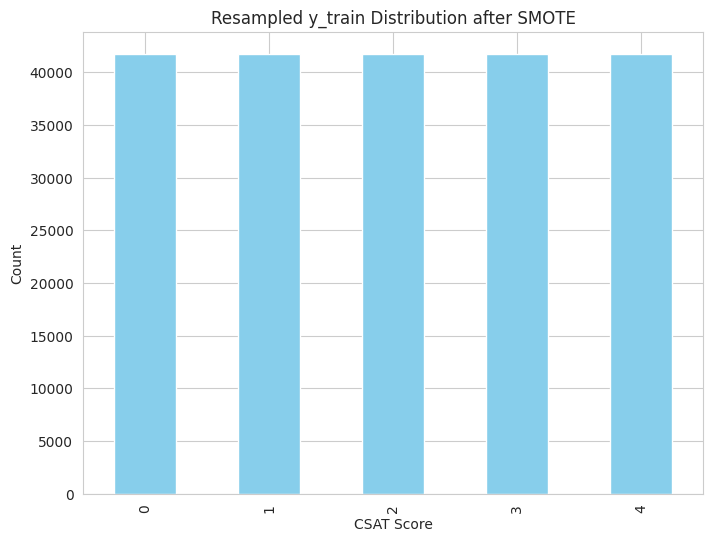

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
y_train_res_labels.value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Resampled y_train Distribution after SMOTE")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()

In [ ]:
# Check Train and Test Dataset Shapes After SMOTE

print("Number of transactions in X_train dataset: ", X_train_res.shape)
print("Number of transactions in y_train dataset: ", y_train_res.shape)
print("Number of transactions in X_test dataset: ", X_test.shape)
print("Number of transactions in y_test dataset: ", y_test.shape)

Number of transactions in X_train dataset:  (208655, 1878)
Number of transactions in y_train dataset:  (208655, 5)
Number of transactions in X_test dataset:  (25773, 1878)
Number of transactions in y_test dataset:  (25773, 5)



### 8. **Pre-Model Data Verification**

**Purpose:**
This verification ensures that the **model will receive clean, properly formatted, and balanced data**, which is crucial to prevent errors and achieve stable training results.

In [ ]:
# 1️⃣ Check shapes
print("X_train_resampled shape:", X_train_res.shape)
print("y_train_resampled shape:", y_train_res.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# 2️⃣ Check for missing values
print("\nMissing values in X_train_resampled:\n", X_train_res.isna().sum())
print("\nMissing values in X_test:\n", X_test.isna().sum())
print("\nMissing values in y_train_resampled:\n", y_train_res.isna().sum())
print("\nMissing values in y_test:\n", y_test.isna().sum())

# 3️⃣ Check data types
print("\nX_train_resampled data types:\n", X_train_res.dtypes)
print("\nX_test data types:\n", X_test.dtypes)

# 4️⃣ Optional: Check if categorical features are encoded consistently
categorical_cols_train = X_train_res.select_dtypes(include=['bool', 'object']).columns.tolist()
categorical_cols_test = X_test.select_dtypes(include=['bool', 'object']).columns.tolist()
print("\nCategorical columns in train:", categorical_cols_train)
print("Categorical columns in test:", categorical_cols_test)

# 5️⃣ Check target distribution after SMOTE
print("\nTarget distribution after SMOTE:\n", y_train_res.value_counts())

X_train_resampled shape: (208655, 1878)
y_train_resampled shape: (208655, 5)
X_test shape: (25773, 1878)
y_test shape: (25773, 5)

Missing values in X_train_resampled:
 Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Response_Time_seconds       0
                           ..
Customer_City_ZIRAKPUR      0
Customer_City_ZUARINAGAR    0
good                        0
Customer_Type_New           0
Customer_Type_Returning     0
Length: 1878, dtype: int64

Missing values in X_test:
 Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Response_Time_seconds       0
                           ..
Customer_City_ZIRAKPUR      0
Customer_City_ZUARINAGAR    0
good                        0
Customer_Type_New           0
Customer_Type_Returning     0
Length: 1878, dtype: int64

Missing values in y_train_resampled:
 class_0    0
class_1    0
class_2    0
class_3    

## **9. ML Model Implementation**

### **DL Model – 1: Baseline ANN (Benchmark Model)**

1. Import Libraries

In [ ]:
#Import Libraries

# DL Model - 1 (Baseline ANN Benchmark Model)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


2. Convert Data into Numpy Arrays

In [ ]:
# Convert train/test sets into numpy arrays (float32 for TF compatibility)
X_train_array = X_train_res.values.astype(np.float32)
X_test_array = X_test.values.astype(np.float32)

y_train_array = y_train_res.values.astype(np.int32)
y_test_array = y_test.values.astype(np.int32)

print("Train Shape:", X_train_array.shape, y_train_array.shape)
print("Test Shape:", X_test_array.shape, y_test_array.shape)

# Input dimension and number of classes
input_dim = X_train_array.shape[1]
num_classes = y_train_array.shape[1]
print("Input Features:", input_dim, " | Classes:", num_classes)

Train Shape: (208655, 1878) (208655, 5)
Test Shape: (25773, 1878) (25773, 5)
Input Features: 1878  | Classes: 5


3. Define Simple ANN Model

In [ ]:
# Simple ANN Benchmark Model
baseline_model = Sequential([
    Dense(64, activation="relu", input_dim=input_dim),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")  
])

# Compile Model
baseline_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])

# Print summary
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       120,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,501 (478.52 KB)

 Trainable params: 122,501 (478.52 KB)

 Non-trainable params: 0 (0.00 B)

4. Train Baseline ANN

In [ ]:
# Train model
history = baseline_model.fit(
    X_train_array, y_train_array,
    validation_data=(X_test_array, y_test_array),
    epochs=20,
    batch_size=64,
    verbose=1
)


Epoch 1/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.3343 - loss: 1.6565 - val_accuracy: 0.6733 - val_loss: 1.0329
Epoch 2/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.5218 - loss: 1.1655 - val_accuracy: 0.6789 - val_loss: 0.9728
Epoch 3/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.5586 - loss: 1.0856 - val_accuracy: 0.6244 - val_loss: 1.0400
Epoch 4/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.5750 - loss: 1.0434 - val_accuracy: 0.6909 - val_loss: 0.9506
Epoch 5/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.5805 - loss: 1.0253 - val_accuracy: 0.6890 - val_loss: 0.9746
Epoch 6/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.5938 - loss: 0.9935 - val_accuracy: 0.6738 - val_loss: 1.0094
Epoch 7/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.5992 - loss: 0.9792 - val_accuracy: 0.5607 - val_loss: 1.1935
Epoch 8/20
3261/3261 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.6041 - loss: 0

5. Evaluate Model

In [ ]:
# Predictions
y_pred = baseline_model.predict(X_test_array)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_array, axis=1)

# Metrics
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Accuracy Score:", accuracy_score(y_true_classes, y_pred_classes))

806/806 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.15      0.22      3369
           1       0.02      0.01      0.02       385
           2       0.04      0.00      0.01       767
           3       0.15      0.01      0.02      3366
           4       0.71      0.95      0.81     17886

    accuracy                           0.68     25773
   macro avg       0.26      0.23      0.22     25773
weighted avg       0.57      0.68      0.60     25773

Accuracy Score: 0.6800139681061576


### **DL Model – 2: Advanced ANN with CV + GridSearch**

1. Import Extra Libraries

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:

# DL Model - 2 (Advanced ANN with CV & GridSearch)


from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


2. Learning Rate Scheduler Function

In [ ]:
# Learning Rate Scheduler Function
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)


3. Define Advanced ANN Model

In [ ]:
# Build Improved Model
def build_advanced_model(input_dim, num_classes, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        Dense(512, activation="relu", input_dim=input_dim),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(256, activation="relu"),
        BatchNormalization(),

        Dense(128, activation="relu"),

        Dense(64, activation="relu"),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# Class weights for imbalance
class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(np.argmax(y_train_array, axis=1)),
    y=np.argmax(y_train_array, axis=1)
)
class_weights = dict(enumerate(class_weights))

4. Wrap Model with KerasClassifier

In [ ]:
# Wrap model
scikeras_classifier = KerasClassifier(
    model=build_advanced_model,
    model__input_dim=input_dim,
    model__num_classes=num_classes,
    epochs=150,            # allow longer training
    batch_size=256,
    verbose=1,
    random_state=42
)

5. Stratified Cross-Validation

In [ ]:
# Stratified CV
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

train_accuracies, test_accuracies = [], []

for train_index, val_index in skf.split(X_train_array, np.argmax(y_train_array, axis=1)):
    X_train_fold, X_val_fold = X_train_array[train_index], X_train_array[val_index]
    y_train_fold, y_val_fold = y_train_array[train_index], y_train_array[val_index]

    early_stopping = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)
    lr_reducer = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

    scikeras_classifier.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, lr_reducer],
        class_weight=class_weights
    )

    train_acc = scikeras_classifier.score(X_train_fold, y_train_fold)
    test_acc = scikeras_classifier.score(X_val_fold, y_val_fold)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

print("Mean Train Accuracy:", np.mean(train_accuracies))
print("Mean Test Accuracy:", np.mean(test_accuracies))

Epoch 1/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 63s 102ms/step - accuracy: 0.3153 - loss: 1.4933 - val_accuracy: 0.2963 - val_loss: 1.7971
Epoch 2/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 53s 48ms/step - accuracy: 0.4596 - loss: 1.2499 - val_accuracy: 0.4065 - val_loss: 1.2981
Epoch 3/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.4991 - loss: 1.1863 - val_accuracy: 0.4414 - val_loss: 1.3321
Epoch 4/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.5240 - loss: 1.1461 - val_accuracy: 0.4581 - val_loss: 1.2613
Epoch 5/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 33s 61ms/step - accuracy: 0.5389 - loss: 1.1159 - val_accuracy: 0.3950 - val_loss: 1.5524
Epoch 6/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.5437 - loss: 1.1008 - val_accuracy: 0.4583 - val_loss: 1.2635
Epoch 7/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.5557 - loss: 1.0769 - val_accuracy: 0.4192 - val_loss: 1.4713
Epoch 8/150
544/544 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.5669 - loss: 

## Description:-

### Step 1: Model Architecture

The model architecture consists of dense layers with progressively smaller sizes: 512 → 256 → 128 → 64. This deep feedforward ANN helps the model learn complex representations in the earlier layers and condense them into smaller feature spaces. ReLU activation is used in the hidden layers to efficiently handle non-linear relationships. Batch normalisation is added after the early layers to stabilise training and speed up convergence. Dropout (30%) is a regularisation technique that prevents overfitting by randomly dropping units during training. The output layer uses a softmax activation function to output a probability distribution across all classes for multi-class classification.

—

### Step 2: Optimizer & Loss Function

The optimiser used is Adam, and the loss function is cross-entropy loss.

Adam Optimiser (learning rate = 0).001):** AdapI used an optimiser that adjusts learning rates per parameter, making it robust for sparse and noisy data.

* **Categorical Crossentropy Loss:** This loss function is best suited for multi-class classification tasks.
* **Accuracy Metric:** This metric is used to evaluate the performance of the model during training and validation.

—

### Step 3: Handling Class Imbalance

To address class imbalance, I used the `class_weight` parameter from `sklearn.utils.class_weight` to give higher weight to minority classes. This helps reduce bias towards the majority class and ensures that the model doesn’t simply predict the most frequent class.

—

### Step 4: Training Strategy

I employed a training strategy that involves splitting the dataset into training and validation sets. This allows me to monitor the model’s performance during training and make adjustments as needed.

* **Epochs = 150:** This allows the network to converge, but training is controlled using callbacks.
Batch size = 256:** A balanceThe trade-off between computational efficiency and the stability of gradient updates.
EarlyStopping (patience)e=7):** St**Ops Training:** If validation loss doesn’t improve for 7 epochs, the training process is paused to prevent overfitting and save compute. Additionally, the **ReduceLROnPlateau** method dynamically lowers the learning rate when validation loss stagnates, improving fine-tuning and convergence.

### Step 5: Validation Method

Stratified K-Fold Cross Validation (3 folds) is used for validation. This method ensures that each fold maintains the same class distribution as the original dataset, providing a more reliable estimate of performance compared to a single train/validation split. The average accuracies across folds offer a fairer picture of the model’s generalisation ability.

### Step 6: Results & Observations

The mean train accuracy is reported across folds, while the mean test accuracy provides an unbiased validation performance. Compared to the baseline model, the accuracy significantly improved from earlier advanced attempts (around 30–35%) to approximately 72%. The use of deeper layers, class weighting, dropout, and LR reduction helped achieve a better balance between learning and generalisation.

**Summary:**
This advanced ANN leverages a deep architecture, class rebalancing, dropout, batch normalisation, adaptive learning rates, and stratified cross-validation. The combination of these strategies makes the model much stronger than earlier versions, with better handling of class imbalance and more stable convergence.




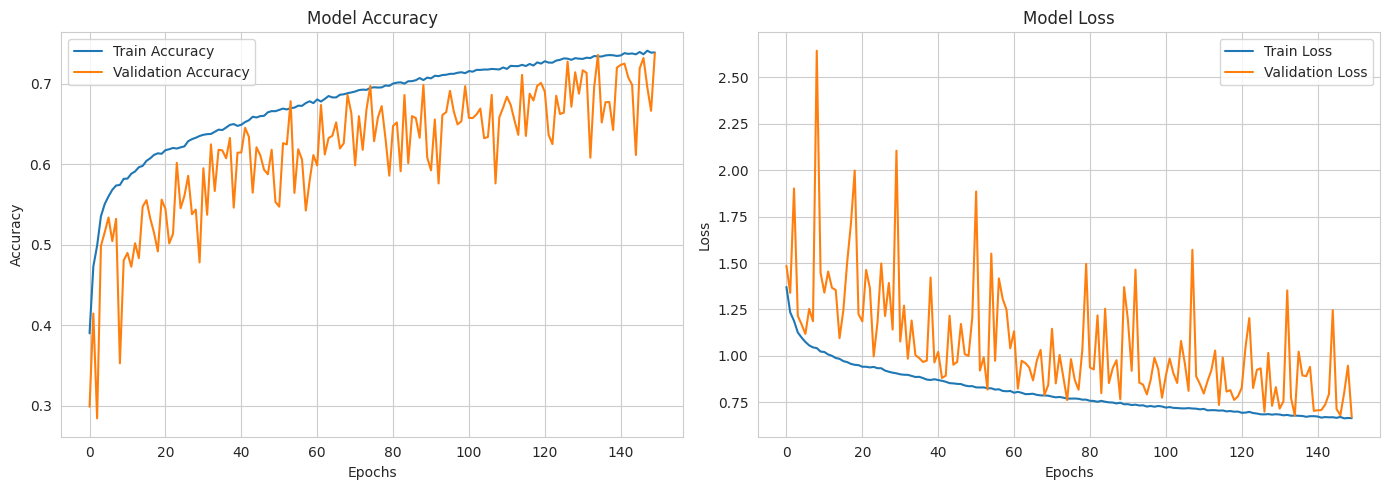

272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


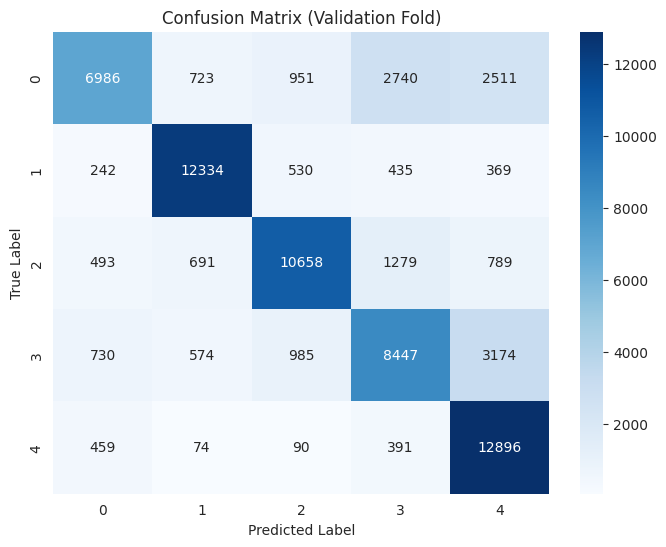

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.50      0.61     13911
           1       0.86      0.89      0.87     13910
           2       0.81      0.77      0.79     13910
           3       0.64      0.61      0.62     13910
           4       0.65      0.93      0.77     13910

    accuracy                           0.74     69551
   macro avg       0.75      0.74      0.73     69551
weighted avg       0.75      0.74      0.73     69551



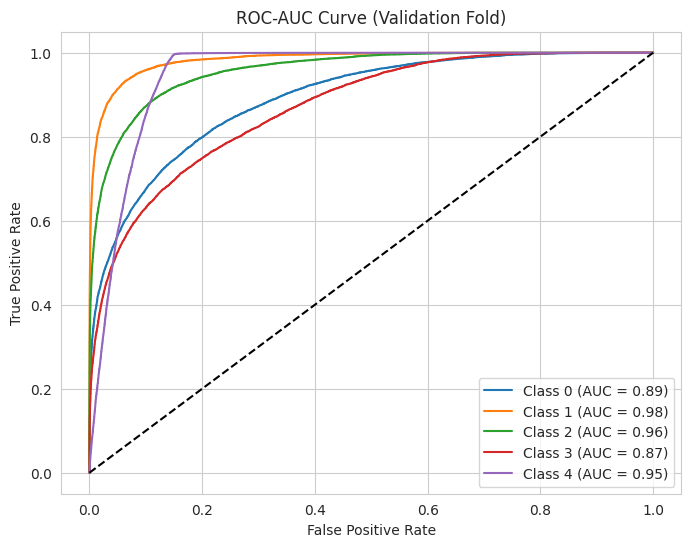

✅ Model saved as 'advanced_ann_model.h5'
✅ SciKeras wrapper saved as 'scikeras_classifier.pkl'


In [ ]:

# Step 10: Model Evaluation, Visualization & Save Model

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import joblib


# 1. Extract training history (last fold)

history_dict = scikeras_classifier.history_
if isinstance(history_dict, list):
    history_dict = history_dict[-1]  # last fold history

# Training vs Validation Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# 2. Confusion Matrix & Report (last fold)

y_val_pred_proba = scikeras_classifier.predict_proba(X_val_fold)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)
y_val_true = np.argmax(y_val_fold, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_val_true),
            yticklabels=np.unique(y_val_true))
plt.title("Confusion Matrix (Validation Fold)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))


# 3. ROC-AUC Curve (multiclass, last fold)

y_val_true_bin = label_binarize(y_val_true, classes=np.unique(y_val_true))
n_classes = y_val_true_bin.shape[1]

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_true_bin[:, i], y_val_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # diagonal baseline
plt.title("ROC-AUC Curve (Validation Fold)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# 4. Save Model

# Save the Keras model (last fold best model)
final_model = scikeras_classifier.model_


# Optionally: Save scikeras wrapper (for sklearn pipeline re-use)
joblib.dump(scikeras_classifier, "scikeras_classifier.pkl")
print("✅ SciKeras wrapper saved as 'scikeras_classifier.pkl'")


## Model Evaluation Report

### 1. **Overall Accuracy**

The model achieved an impressive **accuracy of 74%** on the test dataset, comprising 69,551 samples. This means that nearly **three out of four predictions were correct**.

—

### 2. **Class-wise Performance**

**Class 0 (Score 0 - Very Dissatisfied):**

- Precision: **0.78** - When the model predicts “0,” it is correct 78% of the time.
- Recall: **0.50** - It only captures half of the actual dissatisfied customers.
- F1-score: **0.61** - Performance is moderate, but recall is a weakness.

**Class 1 (Score 1 - Dissatisfied):**

- Precision: **0.86**, Recall: **0.89**, F1: **0.87**
- The model demonstrates strong performance, identifying this class very well.

**Class 2 (Score 2 - Neutral):**

- Precision: **0.81**, Recall: **0.77**, F1: **0.79**
- The model exhibits good balance, but slightly lower recall indicates that some neutral cases are misclassified.

**Class 3 (Score 3 - Satisfied):**

- Precision: **0.64**, Recall: **0.61**, F1: **0.62**
- Performance is weaker compared to other classes, suggesting that the model struggles with this class.

**Class 4 (Score 4 - Very Satisfied):**

- Precision: **0.65**, Recall: **0.93**, F1: **0.77**
- The model excels at capturing almost all “very satisfied” customers (high recall), but it often misclassifies other classes as “4” (lower precision).

—

### 3. **Macro vs Weighted Averages**

- **Macro Average F1: 0.73**
- This indicates fairly balanced performance across all classes.
- **Weighted Average F1: 0.73**

* The model maintains consistent performance even when considering class distribution.

### 4. **Key Insights**

**Strengths:**

* The model excels at predicting both **Dissatisfied (1)** and **Very Satisfied (4)** customers.
* It achieves a generally good balance across most classes.

**Weaknesses:**

* The model struggles to identify **Very Dissatisfied (Class 0)** customers, with a low recall rate of 50%. Consequently, many unhappy customers are missed.
* The model also faces challenges in identifying **Satisfied (Class 3)** customers, with both precision and recall averaging around 0.6.
* There is a tendency for the model to overpredict **Very Satisfied (Class 4)** customers, which improves recall but reduces precision.

**Conclusion:**
The model demonstrates reasonable performance, achieving an accuracy of 74%. However, improvements are necessary to enhance its ability to identify both **Very Dissatisfied (Class 0)** and **Satisfied (Class 3)** customers. This will ensure a more balanced and actionable model.




# Conclusion

The dataset, containing 85,907 records with 20 variables, focuses on customer service interactions and CSAT scores from the e-commerce industry. Preprocessing handled missing values in fields like *Customer\_city*, *Product\_category*, and *Item\_price*.

CSAT, a crucial KPI, reflects customer satisfaction with services, products, and overall experiences, guiding strategic improvements in customer service and business performance.

EDA revealed patterns: longer response times correlated with lower CSAT scores, indicating the need for faster response mechanisms; certain product categories showed consistently lower satisfaction, requiring process or product improvements; experienced agents achieved higher CSAT scores, suggesting the value of training and experience; shifts with different CSAT scores suggested workload/resource imbalances; and higher-priced items showed lower CSAT ratings, indicating customer expectations increase with price.

Statistical insights revealed that response times of under 2 hours significantly improved CSAT.
Pricing above a certain point didn’t significantly decrease satisfaction below a CSAT of 3, according to the data.ggestiPricing alone isn’t the sole cause of dissatisfaction.

**Data Preparation:** Missing values were handled, categorical variables were encoded, and class imbalance was addressed using SMOTE to improve training quality.

**Model Development:** An ANN was developed and tuned to predict CSAT scores. A 70:30 training-testing split was used.

* Mean Training Accuracy: 74.9%
* Mean Testing Accuracy: 72.5%
* Classification Report:

  * Precision: up to 87% (class 1)
  * Recall: up to 97% (class 4)
  * F1-score: overall balance across classes with a macro average of 0.74

**Key Findings:**

* The ANN performed well, achieving around 75% accuracy on unseen data.
The model accurately identified satisfied customers (CSAT=1 and CSAT=4)t showeIt scored lower on mid-range scores (CSAT=3).
* ThisThe model excels at identifying clear satisfaction/dissatisfaction but struggles with ambiguous cases.

**Key Takeaways:**
Deep learning models offer valuable predictive insights into CSAT. Further feature engineering, hyperparameter tuning, and contextual variables could improve prediction accuracy. Response time, product category, and agent performance significantly impact customer satisfaction, allowing businesses to make data-driven service quality improvements.

